#### Trajectory Optimisation

The initial trajectory from code 'Optimisation_baseline' is changed to do it closer to human manipulation (distances changed). So now, the trajectory is composed by:
- Backward motion by distance d
- Forward motion by distance d/2
- Diagonal motion until reaching the table

The initial idea was to do 2 section (back and diagonal), but top overtakes bottom during descent. Maybe will try later to implement this trajectory when both speeds and distances are optimized.

In this code, the 3 speeds corresponding to each phase are optimised.

Then, the maximum allowed speed to place the cloth flat is also computed by minimizing the motion time.

Import all the functions needed for simulation and wrinkliness calculations, from the 'Final_version_analysis' code.

In [1]:
import sys,os
notebook_dir = os.getcwd()  
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
sys.path.append(parent_dir)
from implementation.Cloth import Cloth 
from implementation.utils import createRectangularMesh
import time
import numpy as np

import polyscope as ps

import matplotlib.pyplot as plt

In [2]:
# -------------------------
# CLOTH TYPES
# -------------------------

CLOTH_TYPES = {

    "RL": {  # Rigid-Light
        "tol": 0.0075,
        "rho": 0.1,
        "delta": 0.1,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 0.1e-4,
        "str": 0.001e-4,
        "thck": 0.9,
    },

    "EL": {  # Elastic-Light
        "tol": 0.0075,
        "rho": 0.1,
        "delta": 0.1,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 10e-4,
        "str": 0.1e-4,
        "thck": 0.9,
    },

    "RH": {  # Rigid-Heavy
        "tol": 0.0075,
        "rho": 0.4,
        "delta": 0.4,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 0.1e-4,
        "str": 0.001e-4,
        "thck": 0.9,
    },

    "EH": {  # Elastic-Heavy
        "tol": 0.0075,
        "rho": 0.3,
        "delta": 0.3,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 10e-4,
        "str": 0.1e-4,
        "thck": 0.9,
    },

    "M": {  # In-between
        "tol": 0.0075,
        "rho": 0.2,
        "delta": 0.2,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 1e-4,
        "str": 0.01e-4,
        "thck": 0.9,
    },
}

# cloth_list = ["RL", "EL", "RH", "EH", "M"] # add more cloth types

In [3]:
def get_grasp_config(name, na):
    
    if name == "G1":
        return [0, na-1]
    
    elif name == "G2":
        return [0, 1, na, na+1, na-2, na-1, 2*na-2, 2*na-1]

    elif name == "G3":
        return (
            list(range(int((na/4)-2), int((na/4)+2)+1)) +
            list(range(int(3*(na/4)-2), int(3*(na/4)+2)+1))
        )
    
    elif name == "G4":
        return (
            list(range(int((na/4)-2), int((na/4)+2)+1)) + 
            list(range(int(3*(na/4)-2), int(3*(na/4)+2)+1)) + 
            list(range(int((na/4)-2+na), int((na/4)+2+na)+1)) + 
            list(range(int(3*(na/4)-2+na), int(3*(na/4)+2+na)+1))
        )
    
    elif name == "G5":
        return list(range(int((na/6)), int(5*(na/6))))

    elif name == "G6":
        return list(range(int((na/4))+1, int(3*(na/4))))

    else:
        raise ValueError("Unknown grasp configuration")

In [4]:
def create_initial_mesh(a=0.6, b=0.9, na=20): # limit nº of nodes to avoid long simulation times andmore stable results
    nb = int(na * (1 + a/b))
    
    X, T = createRectangularMesh(a=a, b=b, na=na, nb=nb, h=0.1)

    # Rotate -90° around X-axis
    theta = -np.pi / 2
    Rx = np.array([[1, 0, 0],
                   [0, np.cos(theta), -np.sin(theta)],
                   [0, np.sin(theta), np.cos(theta)]])
    X = X @ Rx.T

    # Raise above table
    X[:, 2] += 0.50

    return X, T, na, nb  # also return na, nb if needed

Function to run experiment not used, but placed here to see the new definition of the trajectory for this code.

In [5]:
def run_experiment(cloth_type_name, grasp_name):

    X, T, na, nb = create_initial_mesh()  # returns all these 4 values
    name = f"{cloth_type_name}_{grasp_name}"
    clothilde = Cloth(X, T, name)  # Original X unchanged

    # compute a suitable timestep based on the mesh
    dt = clothilde.estimateTimeStep(L=0.9)  # largest lineal length of the mesh

    ## ---------------- Experiment Definition ---------------- ##

    params = CLOTH_TYPES[cloth_type_name]
    inds_ctr = get_grasp_config(grasp_name, na)

    clothilde.preparePolyscope()  # need this to save frames and use polyscope!!

    # use keyword arguments so that ordering mistakes can't occur
    clothilde.setSimulatorParameters(
        dt=dt,
        tol=params["tol"],
        rho=params["rho"],
        delta=params["delta"],
        alpha=params["alpha"],
        kappa=params["kappa"],
        str=params["str"],
        shr=params["shr"],
        mu_f=params["mu_f"],
        mu_s=params["mu_s"],
        thck=params["thck"],
    )

    clothilde.restart()

    ## ---------------- Trajectory ---------------- ##

    # Initial position
    u = clothilde.positions[inds_ctr]
    center = u.mean(axis=0) # Get the center by doing the mean of the node positions (column-wise mean to get single 3D point = geometric center of controlled nodes)
    u = center + (u-center) * 0.95 # will decrease the distance from center by keeping the 0.95 (=95%) of the original distance
    for i in range(200): # 200 iterations x 0.005 seconds (dt = time step) = 1 seconds of simulated time 
       clothilde.simulate(u = u, control = inds_ctr) # increment this section to let the cloth stabilize before starting trajectory
    
    # move it backward by 0.2
    u = clothilde.positions[inds_ctr]
    for i in range(50): 
        u[:,1] += 0.004 # sums every time step to move backward
        clothilde.simulate(u = u, control = inds_ctr)

    # move it forward by d/2 = 0.1
    u = clothilde.positions[inds_ctr]
    for i in range(25): 
        u[:,1] -= 0.004 # subs every time step, but less than above 
        clothilde.simulate(u = u, control = inds_ctr)

    # move it down + forward until reaching table (in Y, needs to go down by b = 0.9 + the adjusting initial height of 0.1, so total of 1)
    u = clothilde.positions[inds_ctr]
    # need Euler angles to do both movements at the same time
    for i in range(276): # 160 iterations x 0.005 seconds (dt = time step) = 0.8 seconds of simulated time
        u[:,1] -= 0.0021 # subs every time step at Z, so does total of 0.416 forward
        u[:,2] -= 0.0033 # sums every time step, so it totally moves 1 down at Y
        clothilde.simulate(u = u, control = inds_ctr)

    # stop sequence and motion
    inds_ctr = [] # release controlled nodes at the end
    u = clothilde.positions[inds_ctr]
    for i in range(400): # 100 iterations x 0.005 seconds (dt = time step) = 0.5 seconds of simulated time
        clothilde.simulate(u = u, control = inds_ctr)
    
    return np.array(clothilde.history_pos), clothilde.Am, clothilde.label, clothilde.faces # need history for plotting and also Am for the video

In [6]:
# before calling this function, we need to do 
# V = Am @ history[-1] -> reconstruction of the final position of the mesh with more resolution using Am

def compute_wrinkle_sigma(V, k=20):
    """
    Compute surface variation (wrinkle intensity) per vertex.

    Parameters:
        V : (N,3) array of vertex positions
        k : number of nearest neighbors

    Returns:
        sigma : (N,) wrinkle intensity values
    """

    N = V.shape[0]
    sigma = np.zeros(N) # vector to store wrinkle intensity for each vertex

    for i in range(N): # loop over each vertex

        # Compute distances to all other points
        diff = V - V[i] # vector from v_i to all other vertices
        dist2 = np.sum(diff**2, axis=1) # squared Euclidean distancew

        # Get k nearest neighbors (excluding itself)
        idx = np.argsort(dist2)[1:k+1] # sort all distances and pick the k closest neighbors
        neighbors = V[idx]

        # Compute local mean to get centroid of neighborhood
        mean = np.mean(neighbors, axis=0)

        # Compute covariance matrix
        centered = neighbors - mean # center points around mean (shift neighbors to centroid)
        C = centered.T @ centered / k # covariance matrix of the neighborhood (3x3) captures local geometry around vertex i

        # Eigenvalues (symmetric matrix)
        eigvals = np.linalg.eigvalsh(C)
        # Sort them ascending 
        lambda1, lambda2, lambda3 = eigvals[2], eigvals[1], eigvals[0]

        # Surface variation = wrinkle intensity
        sigma[i] = lambda3 / (lambda1 + lambda2 + lambda3 + 1e-12)

    return sigma


In [7]:
def vertex_areas(V, F):
    """
    Compute approximate area around each vertex for a quad mesh.
    
    V: (n_verts, 3) vertex positions
    F: (n_faces, 4) quad faces (vertex indices)
    """
    areas = np.zeros(V.shape[0])
    
    # split quads into 2 triangles for area computation
    tris = np.vstack([F[:, [0,1,2]], F[:, [0,2,3]]])
    
    for tri in tris:
        v0, v1, v2 = V[tri[0]], V[tri[1]], V[tri[2]]
        tri_area = 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0))
        areas[tri] += tri_area / 3  # distribute equally to 3 vertices
        
    return areas

In [8]:
def compute_wrinkle_metric_area(V, F, sigma):
    areas = vertex_areas(V, F)
    
    # weighted mean
    W_global = np.sum(sigma * areas) / np.sum(areas)
    
    return W_global

1) Displacements of the trajectory (manually calculated based on time steps and distances taken at each)

All experiments have the same setting, so no need to change this values further on the code.

This section in now modified to match the new trajectory:
- Backward by 50 steps x 0.004/step = 0.2
- Forward by 25 x 0.004/step = 0.1
- Diagonal by 1.29 (315 steps x 0.0029/step = 0.93 down ; 315 steps x 0.0025/step = 0.8 back)

In [9]:
# Constants (calculated from baseline experiment)
# representing the travelled distance at each phase (for each axis))
d_back = np.array([0.0, 0.2, 0.0])
d_forward = np.array([0.0, 0.1, 0.0]) # coords when -0.1 forward
d_end = np.array([0.0, -0.5, -0.93]) # coords after diagonal motion (moves -0.6 forth and -0.93 down)

# total linear displacement
L1 = 0.2
L2 = L1/2
L3 = np.sqrt(0.6**2 + 0.93**2)
L_total = L1 + L2 + L3
lam_a = L1 / L_total
lam_b = (L1 + L2) / L_total

# Divide trajectory by phases, not by equidistant sections
lam_knots = np.array([0.0, lam_a, lam_b, 1.0]) # want to separate trajectory into the 3 motion-phases in sim. (back-forth-diag)

2) Function that gives the displacement from the starting point to that phase lambda so far, along the trajectory.

The trajectory has been divided into 4 points: starting point, point where 1rst move ends, point where 2nd move ends and ending point. It si defined by lam_knots above.

In [10]:
def path_displacement(lam):
    """Return displacement from start for a given phase lam."""
    if lam <= lam_a: # backward phase
        alpha = lam / lam_a
        return alpha * d_back
    elif lam <= lam_b: # forward phase
        alpha = (lam - lam_a) / (lam_b - lam_a)
        return d_back + alpha * (d_forward - d_back)
    else: # diagonal phase
        alpha = (lam - lam_b) / (1.0 - lam_b)
        return d_forward + alpha * (d_end - d_forward)

3) Parametrise the Speed Profile: v(lam) is in units of lam per second to be piecewise linear function of lam.

Control points are just a few, at lam = [0, lam_a, lam_b, 1], so starting, 2 middle and ending points along the path, which corresponds to the 3 different controls in the whole trajectory.

The speeds at these points are the optimisation parameters. BUT THE INITIAL KNOT IS FIXED TO 0 (gripper starts still).

The speed between knots points is linearly interpolated using the start-end knots of the motion phase.

Given a set of speeds, we can generate the sequence of λ values at each simulation time step by integrating forward:

In [11]:
def generate_lambda_sequence(speeds, lam_knots, dt, max_steps=5000):
    """
    speeds: array of speeds at lam_knots
    lam_knots: array of lambda coordinates of control points
    dt: simulation time step
    Returns: list of lambda values at each simulation step (including start and end)
    """
    lam = 0.0
    lam_seq = [lam]
    step = 0
    while lam < 1.0 and step < max_steps:
        # interpolate speed at current lam
        idx = np.searchsorted(lam_knots, lam) - 1
        if idx == len(lam_knots) - 1:
            v = speeds[-1]
        else:
            lam_left = lam_knots[idx]
            lam_right = lam_knots[idx+1]
            v_left = speeds[idx]
            v_right = speeds[idx+1]
            if lam_right > lam_left:
                alpha = (lam - lam_left) / (lam_right - lam_left)
            else:
                alpha = 0.0
            v = v_left + alpha * (v_right - v_left)
        lam += v * dt
        lam_seq.append(lam)
        step += 1
    if lam_seq[-1] > 1.0:
        lam_seq[-1] = 1.0
    return lam_seq

Speeds are constant for each segment, no interpolation done between knot points.

In [12]:
def generate_lambda_sequence(speeds, lam_knots, dt, max_steps=5000):
    """
    speeds: array of speeds at lam_knots (constant per segment)
    lam_knots: array of lambda coordinates of control points
    dt: simulation time step
    Returns: list of lambda values at each simulation step
    """
    lam = 0.0
    lam_seq = [lam]
    step = 0
    
    while lam < 1.0 and step < max_steps:
        # Encuentra en qué segmento estamos
        idx = np.searchsorted(lam_knots, lam, side='right') - 1
        idx = np.clip(idx, 0, len(speeds) - 1)
        
        # Velocidad CONSTANTE del segmento actual (sin interpolación)
        v = speeds[idx]
        
        lam += v * dt
        lam_seq.append(lam)
        step += 1
    
    if lam_seq[-1] > 1.0:
        lam_seq[-1] = 1.0
    
    return lam_seq

4) Objective Function for Optimisation: takes set of speeds, runs full simulation (initial stabilisation + motion + final release) and returns final wrinkliness.

For the stabilisation phase, replicate it and record the positions of the grasped nodes as the start of motion p0.

Then, each step of the motion phase, the target position becomes p0 + path_displacement (next_lam) and simulate.

Lastly, release the cloth with empty control for some steps to let the cloth settle.

Then, wrinkliness is computed on the final mesh.

We could add some penalty to the wrinkliness metric, but not for now!

In [13]:
def objective(speeds, cloth_name, grasp_name, lam_knots, dt_fixed=None, alpha = 0.0):

    # Print what we're testing
    print(f"Testing: v={[f'{x:.3f}' for x in speeds]}")

    # Create cloth and mesh
    X, T, na, nb = create_initial_mesh()
    cloth = Cloth(X, T, f"temp_{cloth_name}_{grasp_name}")

    params = CLOTH_TYPES[cloth_name]
    inds_ctr = get_grasp_config(grasp_name, na)

    # Compute dt if not provided (but we will pass a fixed dt from outside)
    dt = cloth.estimateTimeStep(L=0.9) if dt_fixed is None else dt_fixed
    
    # Only need for visualization, and within this funcion not used
    # cloth.preparePolyscope()  # need this to save frames and use polyscope!!

    cloth.setSimulatorParameters(
        dt=dt,
        tol=params["tol"],
        rho=params["rho"],
        delta=params["delta"],
        alpha=params["alpha"],
        kappa=params["kappa"],
        str=params["str"],
        shr=params["shr"],
        mu_f=params["mu_f"],
        mu_s=params["mu_s"],
        thck=params["thck"],
    )
    
    cloth.restart()

    # ---------- Stabilisation phase ----------
    u = cloth.positions[inds_ctr]
    center = u.mean(axis=0)
    u = center + (u - center) * 0.95
    for _ in range(200):
        cloth.simulate(u=u, control=inds_ctr)

    # ---------- Record start positions ----------
    p0 = cloth.positions[inds_ctr].copy()

    # ---------- Generate lambda sequence ----------
    lam_seq = generate_lambda_sequence(speeds, lam_knots, dt)
    print(f"  Motion phase: {len(lam_seq)} positions, lambda from {lam_seq[0]:.3f} to {lam_seq[-1]:.3f}")

    # ---------- Motion phase ----------
    for i in range(len(lam_seq)-1):
        target = p0 + path_displacement(lam_seq[i+1])
        cloth.simulate(u=target, control=inds_ctr)

    # ---------- Release phase ----------
    inds_ctr = []
    u = cloth.positions[inds_ctr]  # empty array
    for _ in range(400):
        cloth.simulate(u=u, control=inds_ctr)

    # Get FINAL positions directly from cloth.positions (not history)
    final_positions = cloth.positions.copy()
    node_up = 0
    node_down = (nb-1) * na
    
    # Use Y coordinate (index 1) 
    final_up_y = final_positions[node_up, 1]
    final_down_y = final_positions[node_down, 1]

    # ---------- Compute wrinkliness ----------
    V = cloth.Am @ cloth.history_pos[-1]
    sigma = compute_wrinkle_sigma(V, k=50)
    W = compute_wrinkle_metric_area(V, cloth.faces, sigma) # use T, not cloth.faces

    # ---------- Add time penalty to max. speed ----------
    # We want maximum allowed speed to place flat, so minimal motion time
    # lam_seq already computed, so min total time is min nº of steps
    total_time = (len(lam_seq) - 1) * dt

    # ensure wrinkliness outweights any possible gain in time, so always guarantee flatness
    # small values for alpha to have wrinkle at 0
    time_penalty = alpha * total_time # wrinkliness dominates, but still min. time
    # if not penalizing total time, alpha will be set to 0

    # -----------------Orientation penalty----------------
    orientation_penalty = 0
    if final_down_y < final_up_y:  # condition
        orientation_penalty = 10
    
    # objective value
    objective_value = W + time_penalty + orientation_penalty
    
    # Print results
    print(f"Wrinkliness: {W:.6f}, Objective: {objective_value:.6f}")
    
    # final value
    return objective_value, W

5) Run CMA-ES Optimisation

For each combination of cloth type and grasp configuration, we run CMA‑ES to find the best speeds.

First, compute a reasonable initial guess, which is a constant speed that the cloth would use during the whole trajectory (no accelerations, nor different speeds between path sections).

In [14]:
import cma # installed cma first in env.

def optimize_grasp_cloth(cloth_name, grasp_name, seed, alpha = 0.0):
    # Set random seed
    np.random.seed(seed)    

    # Get dt from a temporary cloth (same mesh)
    X, T, na, nb = create_initial_mesh()
    temp_cloth = Cloth(X, T, "temp")
    dt = temp_cloth.estimateTimeStep(L=0.9)
    
    # New average speed based on total steps taken during motion: 
    # 50+25+276 steps, total time = 351*dt, so average speed = 1 / (351*dt)
    avg_speed = 1.0 / (351 * dt)
    print(f"{cloth_name}_{grasp_name}: dt={dt:.5f}, avg_speed={avg_speed:.3f}")
    
    # We have len(lam_knots) speeds (knots: 0.0, lam_a, lam_b, 1.0).
    # The first speed (at lam=0) is fixed to 0; we optimize the remaining (n-1) speeds.
    num_opt_vars = len(lam_knots) - 1

    x0 = [avg_speed] * num_opt_vars  # initial guess for the optimal speeds
    print(f'Initial Guess:{x0}')

    # a speed of 0.1 λ/s with dt = 0.005 gives 2600 overall simulator steps per evaluation
    bounds = [0.1, 3.0]  # reasonable bounds (λ/s)

    # Objective function that takes optimised speeds and adds the fixed initial speed
    # Returns objective value (wrinkliness metric)
    def obj_func(opt_speeds):
        # for constant speeds, no initial speed of 0, just the optimised ones
        full_speeds = list(opt_speeds)
        # for interpolated speeds, initial is 0 and then next speeds at knots
        # full_speeds = [0.0] + list(opt_speeds) # first speed is 0
        # alpha for time min. -> If not penalizing total time, alpha is 0!!
        cost, _ = objective(
        full_speeds,
        cloth_name,
        grasp_name,
        lam_knots,
        dt_fixed=dt,
        alpha=alpha)

        return cost
    
    # CMA-ES options
    es = cma.CMAEvolutionStrategy(
        x0, 0.5, # initial guess of x0 = avg_speed and initial step size = 0.5 (how far the sampled candidates are spread around initial mean x0)
        {'bounds': bounds,
         'maxfevals': 100, # number of evaluations: 500 and 300 too large (didn't improve with more evals.)
         'verbose': -1,
         'tolstagnation': 5, # stop after 5 iterations of no improvement
         'CMA_diagonal': True,
         'seed': seed}  # faster for low dimensions
         # population size ('popsize'): population of candidate solutions for each iteration, 
         # default is a function of nº of params./dimensions (here 3 speeds at 3 control points), giving 8 evals. per it.
    )

    evolution = []  # to store (iteration, best_cost) pairs

    print("\nStarting optimization...")

    while not es.stop():
        solutions = es.ask()
        fitness = [obj_func(s) for s in solutions]
        es.tell(solutions, fitness)
        es.logger.add()
        es.disp()

        # Record after each iteration (after es.tell updates the result)
        evolution.append((es.countiter, es.result.fbest))

        if es.countiter % 5 == 0:
            best = es.result.xbest
            print(f"Iter {es.countiter}: best={es.result.fbest:.6f}")
            print(f"  opt_variables={best}")

    # Best speeds for the optimised ones
    best_opt_speeds = es.result.xbest
    # Add the initial speed to have the 4 speeds of the 4 knot points or NOT
    # for constant speeds, no initial speed of 0, just the optimised ones
    # for interpolated speeds, initial is 0 and then next speeds at knots
    # best_speeds = [0.0] + list(best_opt_speeds) # first speed is 0
    best_speeds = list(best_opt_speeds)
    
    # Value for the nest objective function result
    best_cost = es.result.fbest

    # Compute corresponding W
    best_cost, best_W = objective(
        best_speeds,
        cloth_name,
        grasp_name,
        lam_knots,
        dt_fixed=dt,
        alpha=alpha)

    # return everything we want to further save!!
    return best_speeds, best_cost, best_W, dt, seed, evolution # need also dt for further calculations after calling this function!


6) Loop over all combinations of cloth-grasp

In [31]:
import pickle

# cloth_list = ["RL", "EL", "RH", "EH", "M"] # , "RH", "EH", "M", "L_Mid-E", "H_Mid-E", "R_H-Mid", "E_H-Mid"] # add more cloth types ["RL", "EL", "RH", "EH", "M"] 
# grasp_list = ["G1", "G2", "G3", "G4", "G5", "G6"] # , "G3", "G4", "G5", "G6"] # add more grasp configurations ["G1", "G2", "G3", "G4", "G5", "G6"]

cloth_list = ["RH"]
grasp_list = ["G1"]

results_opt = {}  # dictionary to store best speeds and costs for cloth-grasp exps.

for cloth_name in cloth_list:
    for grasp_name in grasp_list:
        print(f"\nOptimising {cloth_name}-{grasp_name}")
        best_speeds, best_cost, best_W, dt, seed, evolution = optimize_grasp_cloth(cloth_name, grasp_name, seed = 10, alpha = 0.01) # need random seed!!

        # save the best speeds for each phase of trajectory + the best optimised objective value (wrinkliness) across all its.
        results_opt[(cloth_name, grasp_name)] = {
            'speeds': best_speeds, 
            'objective value': best_cost, 
            'W': best_W,
            'dt': dt, 
            'lam_knots': lam_knots, 
            'seed': seed, # save random seed
            'evolution': evolution} # log evolution of objective
        
        # Print comprehensive results
        print(f"\n{'='*80}")
        print(f"✓ OPTIMAL RESULTS for {cloth_name}-{grasp_name}")
        print(f"{'='*80}")

        print(f"\nSummary:")
        print(f"  Speeds: {best_speeds}")
        print(f"  W: {best_W:.6f}")
        print(f"  Objective value: {best_cost:.6f}")

# Save to a pickle file -> change name for different loggings
with open('Optimisation_newtraj_constant_time_0.01_10.pkl', 'wb') as f:
    pickle.dump(results_opt, f) # it saves data as the dictionary given by results_opt above!!


# The CMA-ES Log returns: Iter, #Fevals (nº of functions evals so far), function value (value of ojbective = wrinkliness + penaly),
# axis ratio (how elongated search distr. is), sigma (step size of distr.), min&max std., t[m:s] (time spent so far, accumulates)


Optimising RH-G1
Based on your mesh, your best dt is: 0.002371335656962282
RH_G1: dt=0.00237, avg_speed=1.201
Initial Guess:[np.float64(1.2014338166923473), np.float64(1.2014338166923473), np.float64(1.2014338166923473)]

Starting optimization...
Testing: v=['1.867', '1.559', '0.429']
  Motion phase: 824 positions, lambda from 0.000 to 1.000
Wrinkliness: 0.101781, Objective: 0.121298
Testing: v=['1.197', '1.512', '0.841']
  Motion phase: 465 positions, lambda from 0.000 to 1.000
Wrinkliness: 0.083737, Objective: 0.094740
Testing: v=['1.334', '1.256', '1.204']
  Motion phase: 346 positions, lambda from 0.000 to 1.000
Wrinkliness: 0.040848, Objective: 0.049030
Testing: v=['1.114', '1.418', '1.803']
  Motion phase: 261 positions, lambda from 0.000 to 1.000
Wrinkliness: 0.036699, Objective: 0.042864
Testing: v=['0.719', '1.716', '1.316']
  Motion phase: 355 positions, lambda from 0.000 to 1.000
Wrinkliness: 0.056661, Objective: 0.065055
Testing: v=['1.424', '0.633', '1.269']
  Motion phas

#### Code to skip any combination that already exists in the pickle, and add more missing experiments without redoing it all

It loads the current dictionary, runs the new optimisations, adds the new entries, and saves the updated dictionary back to the same file.

In [ ]:
import pickle

# 1. Load existing results
try:
    with open('Optimisation_results.pkl', 'rb') as f:
        results_opt = pickle.load(f)
    print(f"Loaded {len(results_opt)} existing results.")
except FileNotFoundError:
    results_opt = {}
    print("No existing file found, starting fresh.")

# 2. Define the new cloth(s) and grasps
cloth_list_missing = ["EL"]   # only the missing ones
grasp_list = ["G1", "G2", "G3", "G4", "G5", "G6"]

# 3. Run optimizations for new combinations
for cloth_name in cloth_list_missing:
    for grasp_name in grasp_list:
        # Skip if already present (optional, prevents re-running)
        if (cloth_name, grasp_name) in results_opt:
            print(f"Skipping {cloth_name}-{grasp_name} (already in results).")
            continue
        
        print(f"\nOptimising {cloth_name}-{grasp_name}")
        best_speeds, best_cost, dt, seed, evolution = optimize_grasp_cloth(cloth_name, grasp_name, seed = 10)
        
        results_opt[(cloth_name, grasp_name)] = {
            'speeds': best_speeds,
            'objective value': best_cost,
            'dt': dt,
            'lam_knots': lam_knots,
            'seed': seed,
            'evolution': evolution}

# 4. Save the updated dictionary
with open('Optimisation_results.pkl', 'wb') as f:
    pickle.dump(results_opt, f)
    print(f"Saved {len(results_opt)} total results.")

Loaded 24 existing results.

Optimising EL-G1
Based on your mesh, your best dt is: 0.002371335656962282
EL_G1: dt=0.00237, avg_speed=1.016
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      8 0.000000000000000e+00 1.0e+00 4.31e-01  4e-01  4e-01 1:04.6
    2     16 0.000000000000000e+00 1.0e+00 3.93e-01  3e-01  4e-01 2:13.8
    3     24 1.439724552264522e-04 1.0e+00 3.72e-01  3e-01  4e-01 3:19.1
    4     32 0.000000000000000e+00 1.0e+00 4.67e-01  3e-01  6e-01 4:20.1
    5     40 5.923675585728861e-05 1.0e+00 4.30e-01  3e-01  5e-01 5:23.0
    6     48 4.781915370593618e-06 1.0e+00 3.52e-01  2e-01  4e-01 6:29.3
    7     56 0.000000000000000e+00 1.0e+00 2.82e-01  1e-01  3e-01 7:31.4
    8     64 0.000000000000000e+00 1.0e+00 2.49e-01  1e-01  3e-01 8:35.3
    9     72 0.000000000000000e+00 1.0e+00 2.75e-01  1e-01  3e-01 9:36.8
   10     80 0.000000000000000e+00 1.0e+00 2.64e-01  1e-01  3e-01 10:33.8
   11     88 0.000000000000000e+00 1.0e+00 2.33e-01  1e-01

Print optimal speeds for each experiment

In [15]:
import pickle

# Load opt. results to print speeds
with open('Optimisation_newtraj_time_0.01.pkl', 'rb') as f:
    results_opt = pickle.load(f) # dictionary with the data

for (cloth_name, grasp_name), data in results_opt.items():
    speeds = data['speeds']
    dt = data['dt']
    W = data['W']
    
    # Calculate total time (t = d/v)
    t1 = L1 / speeds[0]
    t2 = L2 / speeds [1]
    t3 = L3 / speeds[2]
    total_time = t1 + t2 + t3

    print(f"Speeds for {cloth_name}_{grasp_name}: {speeds}")
    print(f"Total time for {cloth_name}_{grasp_name}: {total_time}")
    print(f"Final W: {W}")

Speeds for RH_G1: [np.float64(1.0810933357325405), np.float64(0.132750123576986), np.float64(1.6552519204421814)]
Total time for RH_G1: 1.606923421938429
Final W: 0.0


#### Visualisation

With the optimised speeds, simulation is re-ran with the new speeds and videos are saved.

In [16]:
def run_with_speeds(speeds, cloth_name, grasp_name, lam_knots, dt):
    # Create mesh and cloth instance
    X, T, na, nb = create_initial_mesh()
    cloth = Cloth(X, T, f"{cloth_name}_{grasp_name}")
    
    dt = cloth.estimateTimeStep(L=0.9)

    params = CLOTH_TYPES[cloth_name]
    inds_ctr = get_grasp_config(grasp_name, na)

    cloth.preparePolyscope()  # need this to save frames and use polyscope!!

    cloth.setSimulatorParameters(
        dt=dt,
        tol=params["tol"],
        rho=params["rho"],
        delta=params["delta"],
        alpha=params["alpha"],
        kappa=params["kappa"],
        str=params["str"],
        shr=params["shr"],
        mu_f=params["mu_f"],
        mu_s=params["mu_s"],
        thck=params["thck"],
    )
    
    cloth.restart()
    
    # ---------- Stabilisation ----------
    u = cloth.positions[inds_ctr]
    center = u.mean(axis=0)
    u = center + (u - center) * 0.95
    for _ in range(200):
        cloth.simulate(u=u, control=inds_ctr)
    
    p0 = cloth.positions[inds_ctr].copy()
    # ---------- Generate lambda sequence ----------
    lam_seq = generate_lambda_sequence(speeds, lam_knots, dt)
    
    # We'll store the positions of the controlled nodes at each step
    ctrl_pos_history = [p0.copy()]
    
    # Motion phase
    for i in range(len(lam_seq)-1):
        target = p0 + path_displacement(lam_seq[i+1])
        cloth.simulate(u=target, control=inds_ctr)
        ctrl_pos_history.append(cloth.positions[inds_ctr].copy())
    
    # ---------- Release phase ----------
    inds_ctr = []
    u = cloth.positions[inds_ctr]  # empty
    for _ in range(400):
        cloth.simulate(u=u, control=inds_ctr)
    
    # Return relevant data
    print(f'Length History Motion Position: {len(ctrl_pos_history)}')
    return np.array(cloth.history_pos), cloth.Am, cloth.label, lam_seq, np.array(cloth.history_vel)  # need history for plotting and also Am for the video

In [17]:
# Function to save frames
import polyscope as ps
import os
import numpy as np

def save_frames_ps(history_pos, Am, label, folder="frames", step=4):
    os.makedirs(folder, exist_ok=True)
    n_frames = len(history_pos)
    print(f"Saving {n_frames//step} frames to {folder}/")

    for i, frame_idx in enumerate(range(0, n_frames, step)):
        phi_mat = history_pos[frame_idx]
        phi_all = Am @ phi_mat

        ps.get_surface_mesh(label).update_vertex_positions(phi_all)
        ps.screenshot(os.path.join(folder, f"frame_{i:04d}.png"), transparent_bg=False)


        if i % 50 == 0:
            print(f"Saved frame {i} / {n_frames//step}")

In [18]:
#  Function to save video from frames folder

import subprocess
import shutil

def create_video_from_frames(frames_folder, output_video, framerate=20, cleanup = True):
    """
    Create a video from a sequence of frames using ffmpeg.
    
    Args:
        frames_folder: Path to folder containing frame_XXXX.png files
        output_video: Output video filename (e.g., "experiment.mp4")
        framerate: Framerate for the video (default: 20)
        cleanup: If True, delete the frames folder after video creation (default: True)
    """
    try:
        cmd = [
            "ffmpeg",
            "-framerate", str(framerate),
            "-i", f"{frames_folder}/frame_%04d.png",
            "-vf", "scale=trunc(iw/2)*2:trunc(ih/2)*2",
            "-c:v", "libx264",
            "-pix_fmt", "yuv420p",
            "-y",  # overwrite output file without asking
            output_video
        ]
        subprocess.run(cmd, check=True, capture_output=True)
        print(f"Video saved: {output_video}")

        # Clean up frames folder if requested
        if cleanup:
            shutil.rmtree(frames_folder)
            print(f"Removed frames folder: {frames_folder}")

    except subprocess.CalledProcessError as e:
        print(f"Error creating video: {e.stderr.decode()}")
    except FileNotFoundError:
        print("ffmpeg not found. Install it using: brew install ffmpeg")
    except Exception as e:
        print(f"Error during cleanup: {e}")

In [ ]:
# Loop that re-runs experiments with new opt. speeds, which saved above in the pickle file

import itertools
import os
import polyscope as ps
import pickle

# Load opt. results
with open('Optimisation_newtraj_time_0.02.pkl', 'rb') as f:
    results_opt = pickle.load(f) # dictionary with the data


# Loop over all stored results from above (will contain each pair cloth-grasp optimised above)
for (cloth_name, grasp_name), data in results_opt.items(): # get the data from dict. results_opt

    speeds = data['speeds']
    dt = data['dt']
    lam_knots = data['lam_knots']

    print(f"Running opt. simulation for {cloth_name}_{grasp_name}")

    # Run simulation
    history, Am, label, lam_seq, speeds = run_with_speeds(speeds, cloth_name, grasp_name, lam_knots, dt)

    frames_folder = f"frames_{cloth_name}_{grasp_name}_Opt_Temp"
    os.makedirs(frames_folder, exist_ok=True)

    # Fix camera once per experiment
    ps.reset_camera_to_home_view()
    ps.set_view_projection_mode("perspective")
    ps.set_window_size(1500, 1000)

    intrinsics = ps.CameraIntrinsics(fov_vertical_deg=45., fov_horizontal_deg=45.)

    angle = np.radians(120)
    radius = 2.0
    height = 1.75

    # Compute camera position
    cam_x = radius * np.sin(angle)   # horizontal offset
    cam_z = height                    # vertical offset (low, close to table)
    cam_y = radius * np.cos(angle)    # forward/back offset

    # Look at origin
    look_dir = (-cam_x, -cam_y, -cam_z+0.3)
    up_dir = (0, 0, 1) # with the mesh rotated, now the Y-axis is the original Z-axis, so we set up to be along global Z


    extrinsics = ps.CameraExtrinsics(root=(cam_x, cam_y, cam_z), look_dir=look_dir, up_dir=up_dir)

    ps.set_view_camera_parameters(ps.CameraParameters(intrinsics, extrinsics))

    # edges configuration
    mesh = ps.get_surface_mesh(label)

    mesh.set_color((0.2, 0.5, 0.8)) # RGB color of the mesh, blue for all meshes/cases (if not determined, each mesh for each new experiment will have different colors when polyscope registers them)
    mesh.set_edge_color((0.0, 0.0, 0.0))  # RGB color of the edges, black for edges
    mesh.set_edge_width(0.9)             # thickness of the edges

    # Save frames
    save_frames_ps(history, Am, label, folder=frames_folder, step=8)

    print(f"Finished saving frames for {cloth_name}_{grasp_name}")

    # Create video from frames
    create_video_from_frames(frames_folder, f"{cloth_name}_{grasp_name}_NewTraj_time_0.02.mp4", cleanup = True)

Running opt. simulation for RH_G1
Based on your mesh, your best dt is: 0.002371335656962282
Length History Motion Position: 345
Saving 118 frames to frames_RH_G1_Opt_Temp/
Saved frame 0 / 118
Saved frame 50 / 118
Saved frame 100 / 118
Finished saving frames for RH_G1
Video saved: RH_G1_NewTraj_time_0.02.mp4
Removed frames folder: frames_RH_G1_Opt_Temp


: 

For missing videos without running them all again

In [ ]:
# Loop that re-runs experiments with new opt. speeds, but only saves videos for missing ones

import itertools
import os
import polyscope as ps

# Load opt. results
with open('Optimisation_results.pkl', 'rb') as f:
    results_opt = pickle.load(f) # dictionary with the data

# Loop over all stored results from above (will contain each pair cloth-grasp optimised above)
for (cloth_name, grasp_name), data in results_opt.items(): # get the data from dict. results_opt

    video_filename = f"{cloth_name}_{grasp_name}_Opt.mp4"
    
    # Check if video already exists
    if os.path.exists(video_filename):
        print(f"Video {video_filename} already exists, skipping.")
        continue
    
    speeds = data['speeds']
    dt = data['dt']
    lam_knots = data['lam_knots']

    print(f"Running opt. simulation for {cloth_name}_{grasp_name}")

    # Run simulation
    history, Am, label, lam_seq = run_with_speeds(speeds, cloth_name, grasp_name, lam_knots, dt)

    frames_folder = f"frames_{cloth_name}_{grasp_name}_Opt"
    os.makedirs(frames_folder, exist_ok=True)

    # Fix camera once per experiment
    ps.reset_camera_to_home_view()
    ps.set_view_projection_mode("perspective")
    ps.set_window_size(1854, 1011)

    intrinsics = ps.CameraIntrinsics(fov_vertical_deg=45., fov_horizontal_deg=45.)

    angle = np.radians(120)
    radius = 2.0
    height = 1.75

    # Compute camera position
    cam_x = radius * np.sin(angle)   # horizontal offset
    cam_z = height                    # vertical offset (low, close to table)
    cam_y = radius * np.cos(angle)    # forward/back offset

    # Look at origin
    look_dir = (-cam_x, -cam_y, -cam_z)
    up_dir = (0, 0, 1) # with the mesh rotated, now the Y-axis is the original Z-axis, so we set up to be along global Z

    extrinsics = ps.CameraExtrinsics(root=(cam_x, cam_y, cam_z), look_dir=look_dir, up_dir=up_dir)

    ps.set_view_camera_parameters(ps.CameraParameters(intrinsics, extrinsics))

    # edges configuration
    mesh = ps.get_surface_mesh(label)

    mesh.set_color((0.2, 0.5, 0.8)) # RGB color of the mesh, blue for all meshes/cases (if not determined, each mesh for each new experiment will have different colors when polyscope registers them)
    mesh.set_edge_color((0.0, 0.0, 0.0))  # RGB color of the edges, black for edges
    mesh.set_edge_width(0.9)             # thickness of the edges

    # Save frames
    save_frames_ps(history, Am, label, folder=frames_folder, step=8)

    print(f"Finished saving frames for {cloth_name}_{grasp_name}")

    # Create video from frames
    create_video_from_frames(frames_folder, video_filename)

------------------------------------

#### Plotting for analysis / summary

Loop to plot the optimised speed profile for each experiment.

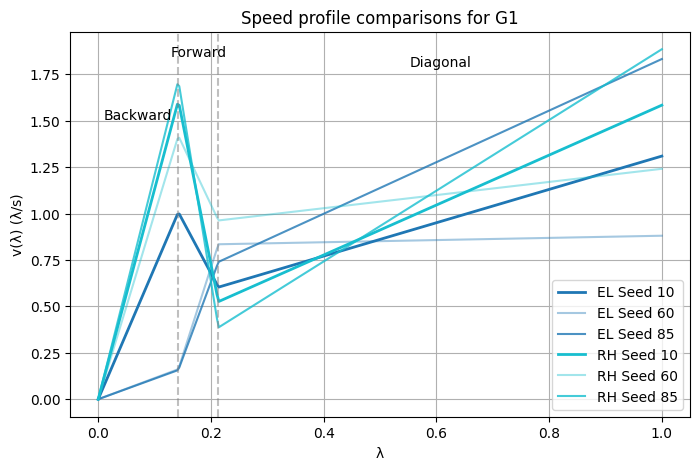

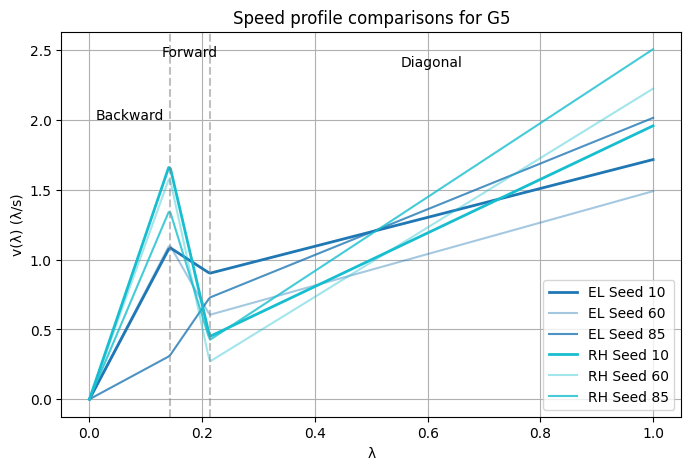

In [22]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open('Optimisation_results_seed10_spline.pkl', 'rb') as f:
    results_opt = pickle.load(f)

with open('Optimisation_results_seed60_spline.pkl', 'rb') as f:
    results_time = pickle.load(f)

with open('Optimisation_results_seed85_spline.pkl', 'rb') as f:
    results_85 = pickle.load(f)

# collect unique grasps & cloths
grasps = sorted({g for (_, g) in results_opt.keys()}  | {g for (_, g) in results_time.keys()} | {g for (_, g) in results_85.keys()})
cloths = sorted({c for (c, _) in results_opt.keys()} | {c for (c, _) in results_time.keys()} | {c for (c, _) in results_85.keys()})

# colors for plotting, one per cloth type
colors = {cloth: col for cloth, col in zip(cloths, plt.cm.tab10(np.linspace(0, 1, len(cloths))))}

for grasp_name in grasps: # If one plot containing all G in same figure, swap loops: cloth outer, grasp inner
    plt.figure(figsize=(8, 5))
    for cloth_name in cloths:
        key = (cloth_name, grasp_name)
        lam_dense = np.linspace(0, 1, 300)

        if key in results_opt:
            data = results_opt[key]
            speeds = np.asarray(data['speeds'])
            lam_knots = np.asarray(data['lam_knots'])
            v_dense = np.interp(lam_dense, lam_knots, speeds)
            
            plt.plot(lam_dense, v_dense, label=f"{cloth_name} Seed 10", color = colors[cloth_name], linewidth = 2)

        if key in results_time:
            data = results_time[key]
            speeds = np.asarray(data['speeds'])
            lam_knots = np.asarray(data['lam_knots'])
            v_dense = np.interp(lam_dense, lam_knots, speeds)
            
            plt.plot(lam_dense, v_dense, label=f"{cloth_name} Seed 60", color = colors[cloth_name], alpha = 0.4) # alpha makes color lighter by that value!!

        if key in results_85:
            data = results_85[key]
            speeds = np.asarray(data['speeds'])
            lam_knots = np.asarray(data['lam_knots'])
            v_dense = np.interp(lam_dense, lam_knots, speeds)
            
            plt.plot(lam_dense, v_dense, label=f"{cloth_name} Seed 85", color = colors[cloth_name], alpha = 0.8) # alpha makes color lighter by that value!!


    # Create vertical lines to separate phases and add text labels per phase
    plt.axvline(lam_a, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(lam_b, color='gray', linestyle='--', alpha=0.5)
    plt.text(lam_a/2, max(speeds)*0.8, 'Backward', ha='center') # inputs are: (x, y) coordinates of text, text string, and ha for horizontal alignment (right, center, left)
    plt.text((lam_a+lam_b)/2, max(speeds)*0.98, 'Forward', ha='center')
    plt.text((lam_b+1)/2, max(speeds)*0.95, 'Diagonal', ha='center')

    # Plor configuration
    plt.title(f'Speed profile comparisons for {grasp_name}')
    plt.xlabel('λ')
    plt.ylabel('v(λ) (λ/s)')
    plt.legend()
    plt.grid(True)
    plt.show()

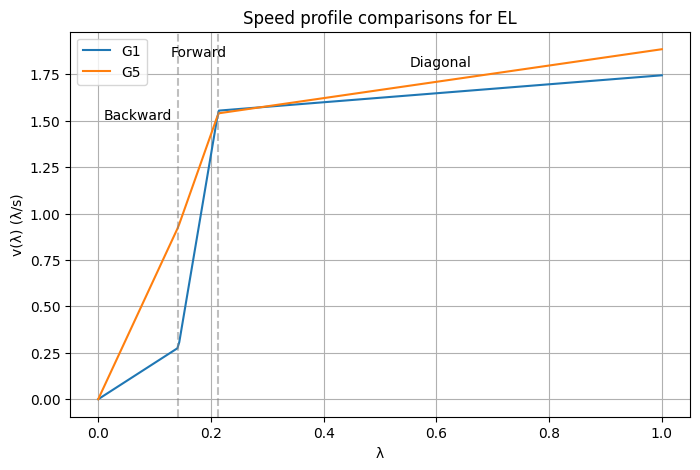

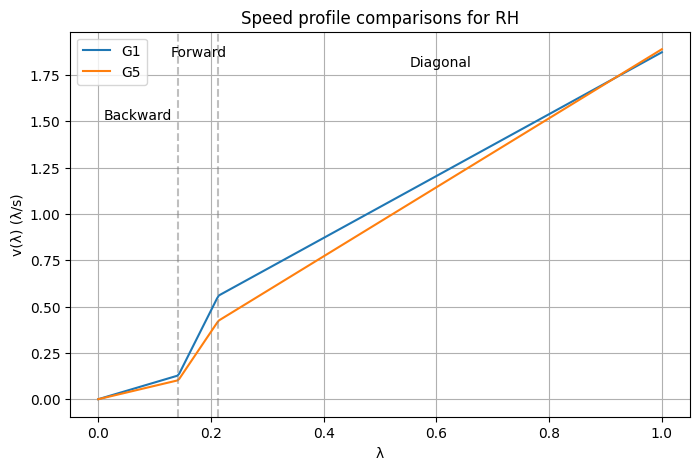

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open('Optimisation_results_new.pkl', 'rb') as f:
    results_opt = pickle.load(f)

# collect unique grasps & cloths
grasps = sorted({g for (_, g) in results_opt.keys()})
cloths = sorted({c for (c, _) in results_opt.keys()})

for cloth_name in cloths: # If one plot containing all G in same figure, swap loops: cloth outer, grasp inner
    plt.figure(figsize=(8, 5))
    for grasp_name in grasps:
        key = (cloth_name, grasp_name)
        if key not in results_opt:
            continue
        data = results_opt[key]
        speeds = np.asarray(data['speeds'])
        lam_knots = np.asarray(data['lam_knots'])

        lam_dense = np.linspace(0, 1, 300)
        v_dense = np.interp(lam_dense, lam_knots, speeds)

        plt.plot(lam_dense, v_dense, label=grasp_name) # change here depending if plot for grasps or cloth -> legend

    plt.axvline(lam_a, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(lam_b, color='gray', linestyle='--', alpha=0.5)
    plt.text(lam_a/2, max(speeds)*0.8, 'Backward', ha='center')
    plt.text((lam_a+lam_b)/2, max(speeds)*0.98, 'Forward', ha='center')
    plt.text((lam_b+1)/2, max(speeds)*0.95, 'Diagonal', ha='center')
    
    plt.title(f'Speed profile comparisons for {cloth_name}') # change here depending if plot for grasps or cloth
    plt.xlabel('λ')
    plt.ylabel('v(λ) (λ/s)')
    plt.legend()
    plt.grid(True)
    plt.show()

Running opt. simulation for RH_G1
Based on your mesh, your best dt is: 0.002371335656962282


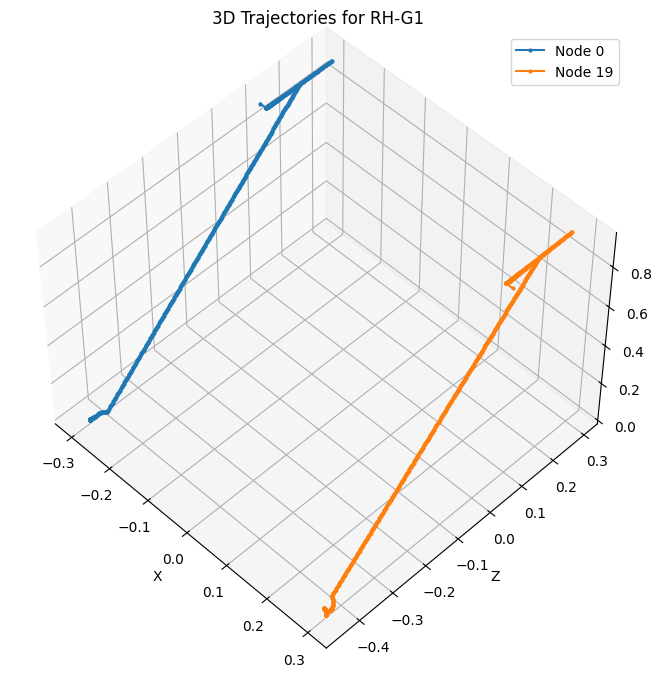

Running opt. simulation for RH_G5
Based on your mesh, your best dt is: 0.002371335656962282


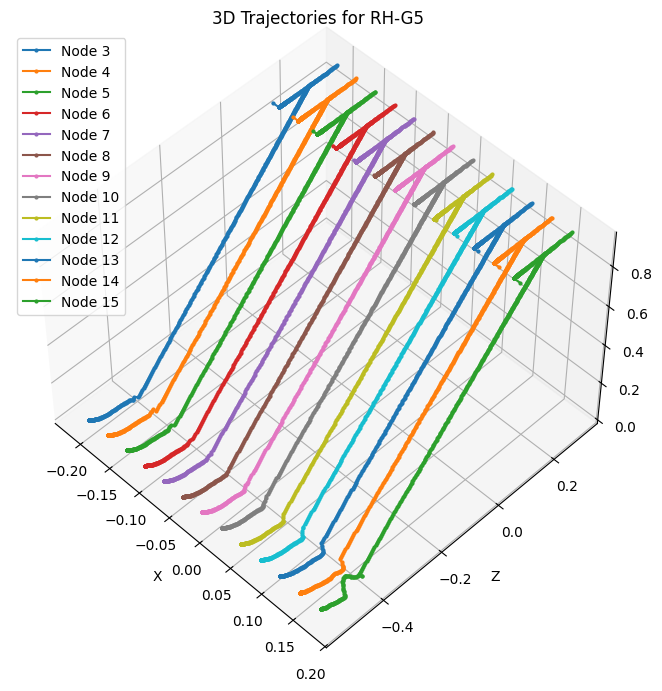

Running opt. simulation for EL_G1
Based on your mesh, your best dt is: 0.002371335656962282


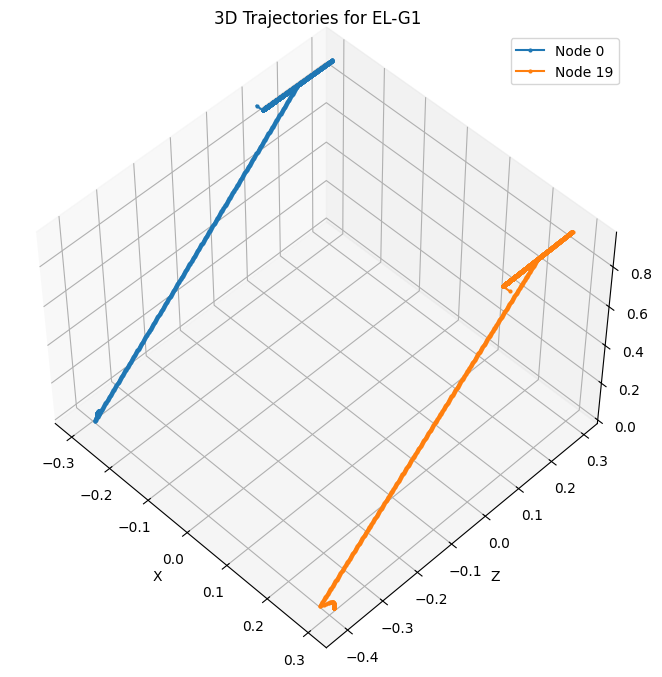

Running opt. simulation for EL_G5
Based on your mesh, your best dt is: 0.002371335656962282


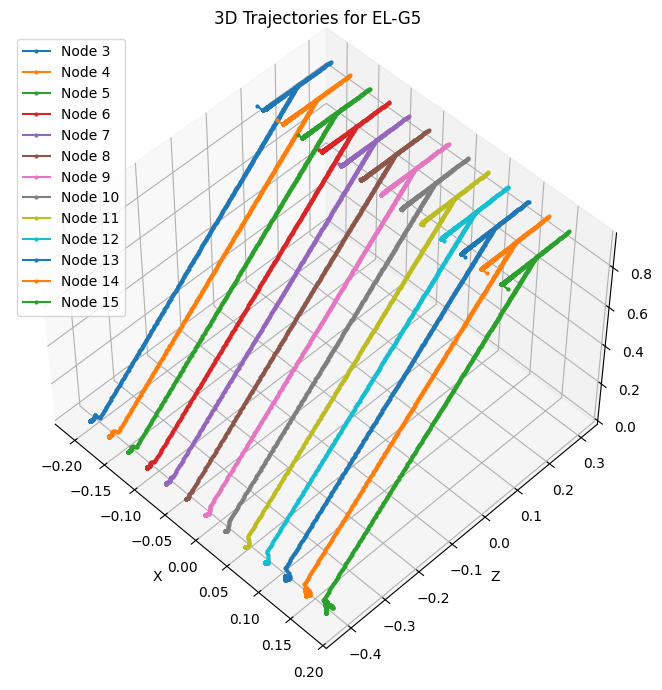

In [20]:
## Loop that re-runs experiments with new opt. speeds, which saved above in the pickle file

import itertools
import os
import polyscope as ps

# Load opt. results
with open('Optimisation_results_seed60_spline.pkl', 'rb') as f:
    results_opt = pickle.load(f) # dictionary with the data


# Loop over all stored results from above (will contain each pair cloth-grasp optimised above)
for (cloth_name, grasp_name), data in results_opt.items(): # get the data from dict. results_opt

    speeds = data['speeds']
    dt = data['dt']
    lam_knots = data['lam_knots']

    print(f"Running opt. simulation for {cloth_name}_{grasp_name}")

    # Run simulation
    history_pos, Am, label, lam_seq, history_speeds = run_with_speeds(speeds, cloth_name, grasp_name, lam_knots, dt)

    na = 20
    inds_ctr = get_grasp_config(grasp_name, na) # get controlled nodes

    # Plot 3D trajectory of nodes
    fig3D = plt.figure(figsize=(10, 8))
    ax = fig3D.add_subplot(111, projection='3d')

    # Camera view: adjusted to see it from the front
    ax.view_init(elev=50, azim=-45)

    for node_id in inds_ctr: # plot trajectory for each selected node
        trajectory = history_pos[:, node_id, :] # get the history_pos of the nodes
        
        ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], label=f'Node {node_id}', marker='o', markersize=2) # plot XYZ given by (X, Z, Y)

    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_zlabel('Y')
    ax.legend()
    plt.title(f'3D Trajectories for {cloth_name}-{grasp_name}')
    plt.show()

Plot of the optimised speeds on simulation

Running opt. simulation for RH_G1
Based on your mesh, your best dt is: 0.002371335656962282
[polyscope] Backend: openGL3_glfw -- Loaded openGL version: 4.3 (Core Profile) Mesa 25.2.8-0ubuntu0.24.04.1


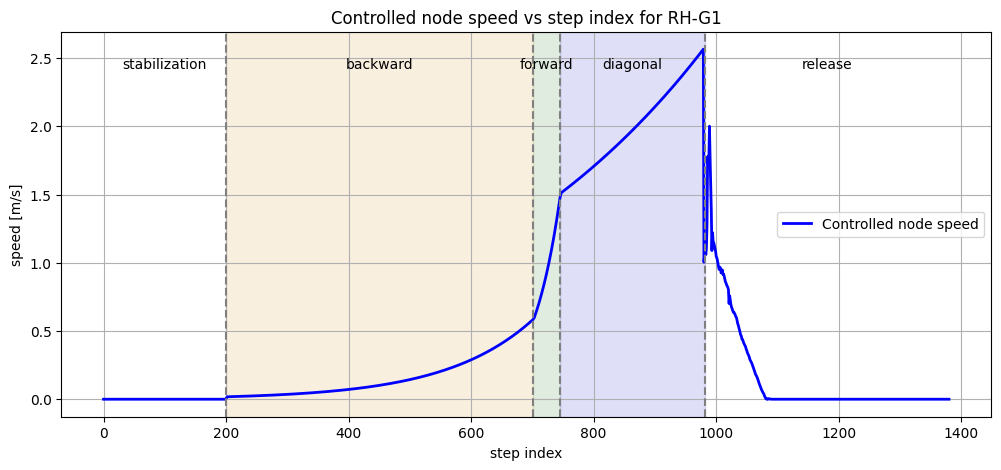

Running opt. simulation for RH_G5
Based on your mesh, your best dt is: 0.002371335656962282


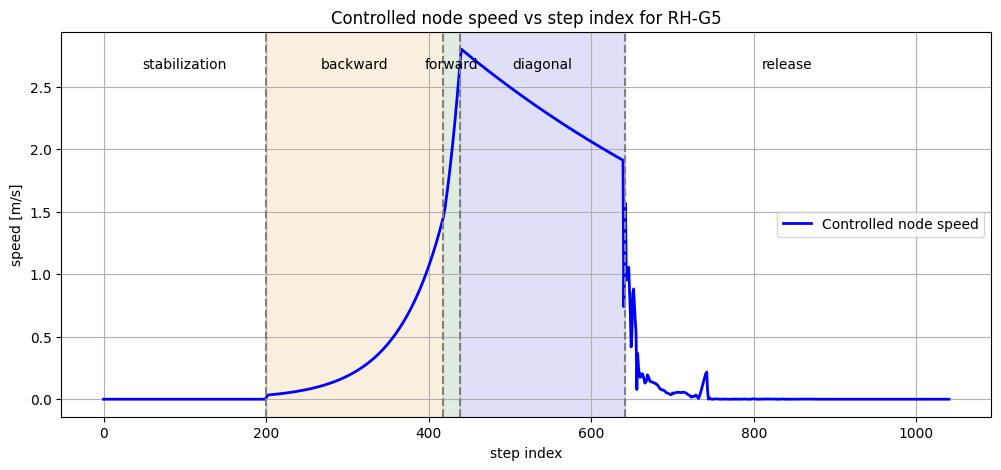

Running opt. simulation for EL_G1
Based on your mesh, your best dt is: 0.002371335656962282


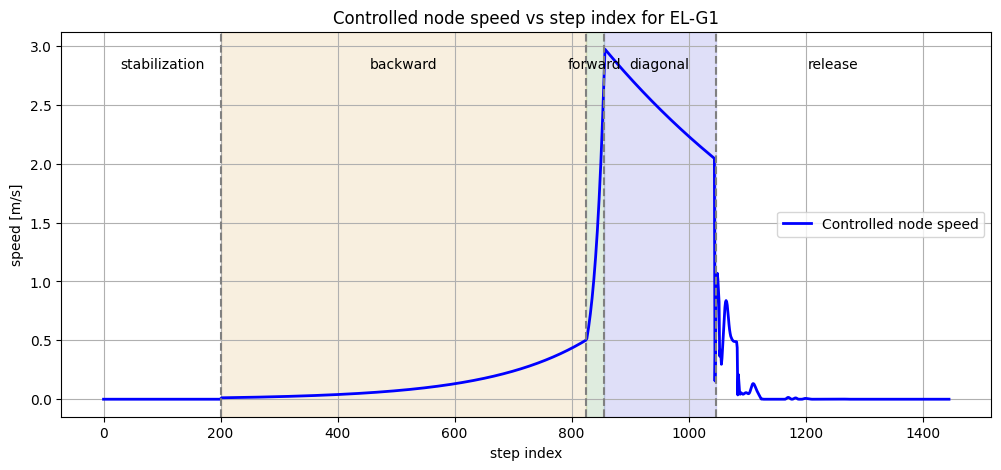

Running opt. simulation for EL_G5
Based on your mesh, your best dt is: 0.002371335656962282


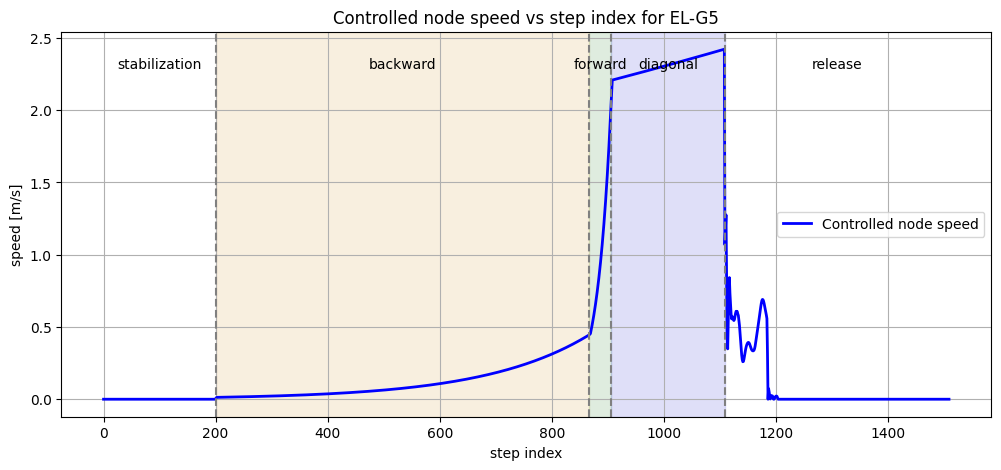

In [18]:
## Loop that re-runs experiments with new opt. speeds, which saved above in the pickle file

import itertools
import os
import polyscope as ps

# Load opt. results
with open('Optimisation_results_seed85.pkl', 'rb') as f:
    results_opt = pickle.load(f) # dictionary with the data


# Loop over all stored results from above (will contain each pair cloth-grasp optimised above)
for (cloth_name, grasp_name), data in results_opt.items(): # get the data from dict. results_opt

    speeds = data['speeds']
    dt = data['dt']
    lam_knots = data['lam_knots'] # [0, lam_a, lam_b, 1]
    lam_a, lam_b = lam_knots[1], lam_knots[2]

    print(f"Running opt. simulation for {cloth_name}_{grasp_name}")

    history_pos, Am, label, lam_seq, history_vel = run_with_speeds(speeds, cloth_name, grasp_name, lam_knots, dt)

    inds_ctr = get_grasp_config(grasp_name, na=20)

    ctrl_vel = history_vel[:, inds_ctr, :]        # (nt, n_ctrl, 3)
    ctrl_speed = np.linalg.norm(ctrl_vel, axis=2) # (nt, n_ctrl)

    # plot by time steps: divide trajectory per steps
    nt = ctrl_speed.shape[0]
    stab_steps = 200
    motion_steps = len(lam_seq)
    release_steps = 400

    # 1. Find the step indices where λ crosses lam_a and lam_b
    # Find first index where lam_seq >= lam_a
    idx_a = np.argmax(lam_seq >= lam_a)          # index in lam_seq (≥ 1)
    # Find first index where lam_seq >= lam_b
    idx_b = np.argmax(lam_seq >= lam_b)          # index in lam_seq (≥ idx_a)
    # Convert to full simulation step indices
    trans_step_a = stab_steps + (idx_a - 1)      # step that ends the backward phase
    trans_step_b = stab_steps + (idx_b - 1)      # step that ends the forward phase

    # 2. Build mask to hide the spike steps
    phase_change_idx = [1, stab_steps + 1, stab_steps + motion_steps]
    mask_steps = set(phase_change_idx)

    # First motion step (spike from stabilization)
    # Add transition steps 
    mask_steps.add(stab_steps)                   # first motion step (index 200)
    mask_steps.add(trans_step_a+1)                 # first step after backward
    mask_steps.add(trans_step_b+1)                 # first step after forward

    # Keep only indices within the valid range
    mask_steps = {i for i in mask_steps if 0 <= i < nt} 

    # Create a boolean mask for plotting
    mask = np.ones(nt, dtype=bool)
    mask[list(mask_steps)] = False

    # 3. Determine step ranges for the three sub‑phases
    # Backward phase: steps with target λ < lam_a  -> indices [stab_steps, trans_step_a)
    # Forward phase: steps with target λ < lam_b and ≥ lam_a -> [trans_step_a, trans_step_b)
    # Diagonal phase: steps with target λ ≥ lam_b -> [trans_step_b, stab_steps + motion_steps)
    backward_range = (stab_steps, trans_step_a)
    forward_range  = (trans_step_a, trans_step_b)
    diagonal_range = (trans_step_b, stab_steps + motion_steps)

    # total time of simulaton in secs.
    steps = np.arange(nt)
    t = steps * dt

    fig, ax = plt.subplots(figsize=(12, 5))

    # take only 1 controlled node, as all look the same (same speed)
    ax.plot(steps[mask], ctrl_speed[:, 0][mask], label='Controlled node speed', color='blue', linewidth=2)

    # phase regions
    # Shade the three sub‑phases (optional)
    ax.axvspan(*backward_range, color='orange', alpha=0.1)
    ax.axvspan(*forward_range,  color='green',  alpha=0.1)
    ax.axvspan(*diagonal_range, color='blue',   alpha=0.1)

    # Optionally, keep the overall motion shading with a lower alpha
    ax.axvspan(stab_steps, stab_steps + motion_steps, color='gray', alpha=0.05)

    # Mark the boundaries with vertical lines
    ax.axvline(stab_steps, color='gray', linestyle='--')
    ax.axvline(trans_step_a, color='gray', linestyle='--')
    ax.axvline(trans_step_b, color='gray', linestyle='--')
    ax.axvline(stab_steps + motion_steps, color='gray', linestyle='--')

    # Annotate phases (place text at the centre of each sub‑phase)
    ylim = ax.get_ylim()
    text_y = ylim[1] * 0.9
    ax.text((backward_range[0] + backward_range[1]) / 2, text_y, 'backward', ha='center')
    ax.text((forward_range[0] + forward_range[1]) / 2, text_y, 'forward', ha='center')
    ax.text((diagonal_range[0] + diagonal_range[1]) / 2, text_y, 'diagonal', ha='center')
    ax.text(stab_steps / 2, text_y, 'stabilization', ha='center')
    ax.text(stab_steps + motion_steps + release_steps / 2, text_y, 'release', ha='center')

    ax.set_xlabel('step index')
    ax.set_ylabel('speed [m/s]')
    ax.set_title(f'Controlled node speed vs step index for {cloth_name}-{grasp_name}')
    ax.grid(True)
    ax.legend()
    plt.show()



Plot for the optimised theoretical speeds + simulated speeds

Running opt. simulation for RH_G1


Based on your mesh, your best dt is: 0.002371335656962282


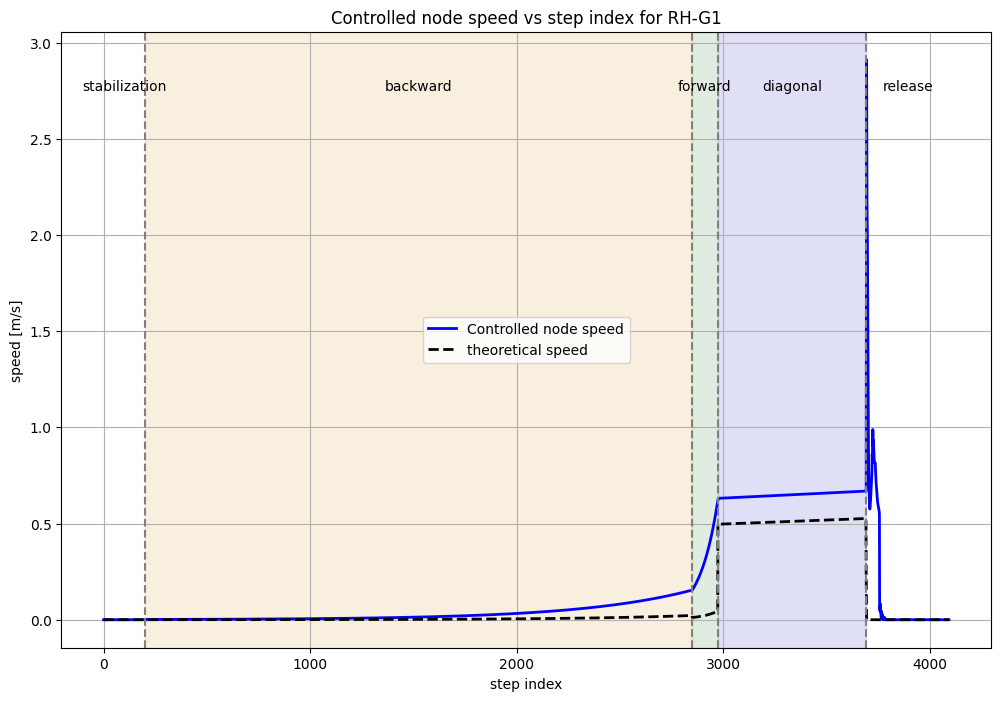

Running opt. simulation for RH_G5
Based on your mesh, your best dt is: 0.002371335656962282


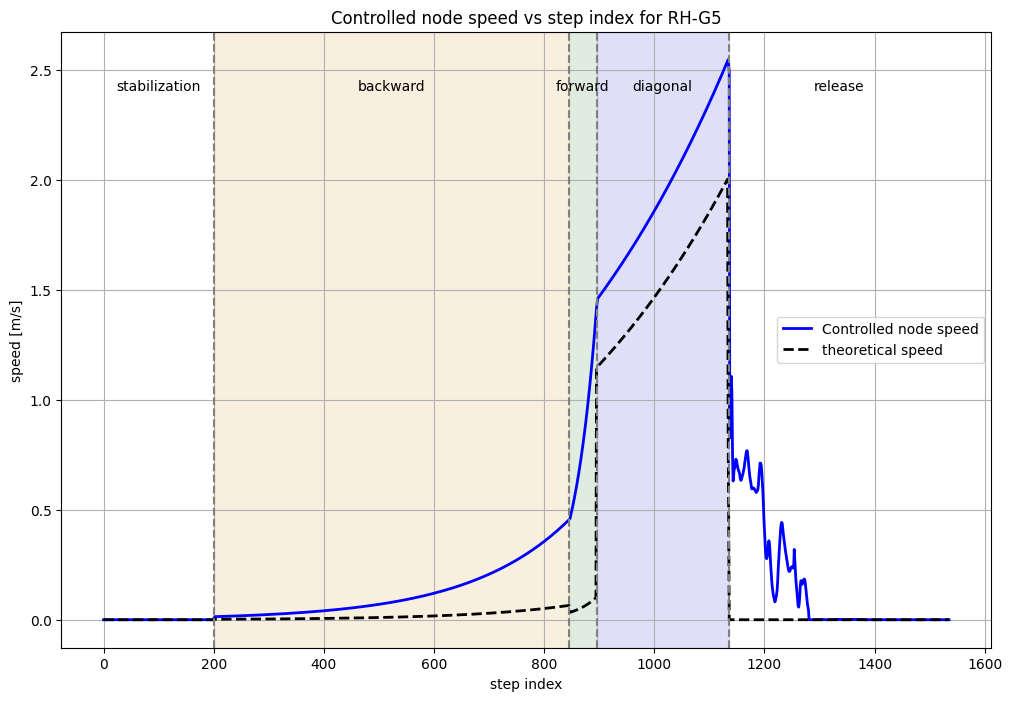

Running opt. simulation for EL_G1
Based on your mesh, your best dt is: 0.002371335656962282


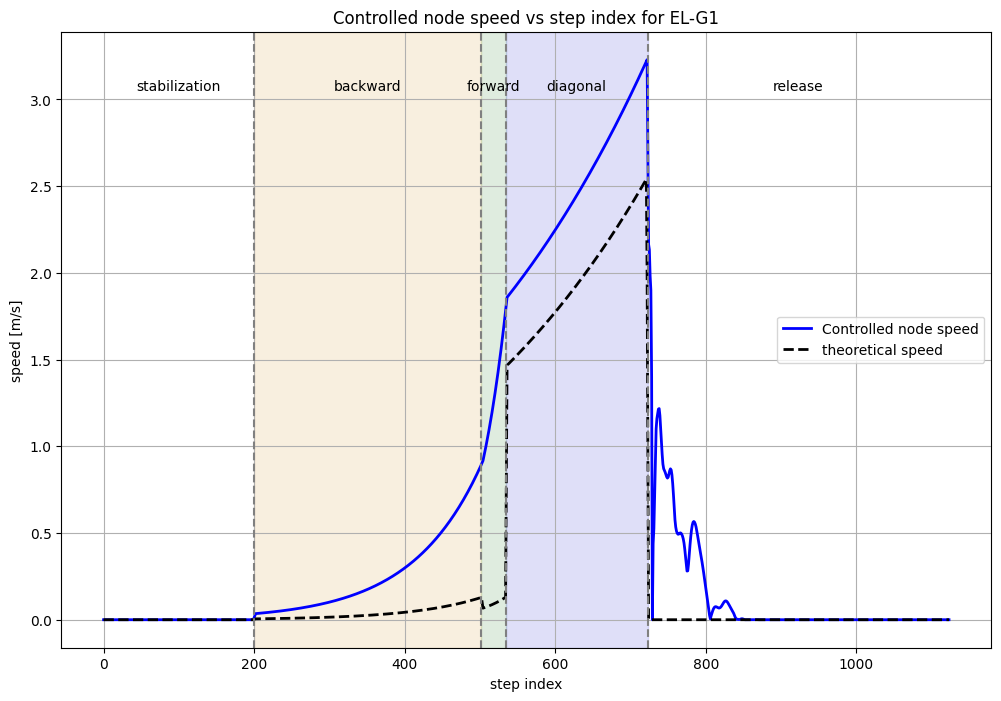

Running opt. simulation for EL_G5
Based on your mesh, your best dt is: 0.002371335656962282


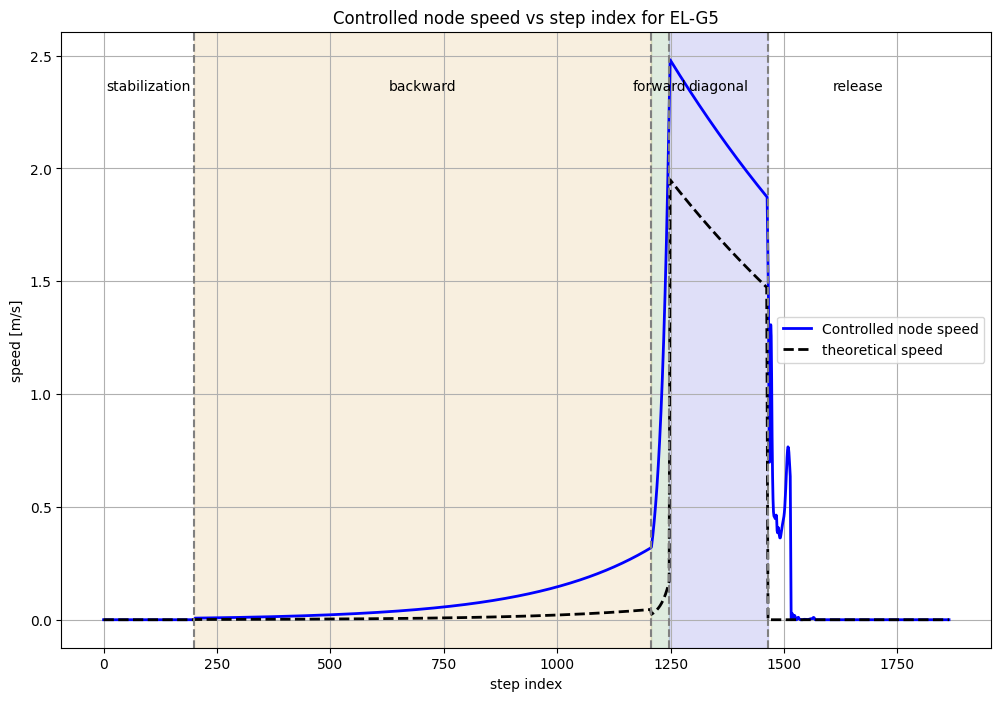

In [20]:
# Load opt. results
with open('Optimisation_results_seed60.pkl', 'rb') as f:
    results_opt = pickle.load(f) # dictionary with the data

for (cloth_name, grasp_name), data in results_opt.items():
    # ... (as before, retrieve speeds, dt, lam_knots, run simulation, get ctrl_speed, etc.)
    speeds = data['speeds']
    dt = data['dt']
    lam_knots = data['lam_knots'] # [0, lam_a, lam_b, 1]
    lam_a, lam_b = lam_knots[1], lam_knots[2]

    print(f"Running opt. simulation for {cloth_name}_{grasp_name}")

    history_pos, Am, label, lam_seq, history_vel = run_with_speeds(speeds, cloth_name, grasp_name, lam_knots, dt)

    inds_ctr = get_grasp_config(grasp_name, na=20)

    ctrl_vel = history_vel[:, inds_ctr, :]        # (nt, n_ctrl, 3)
    ctrl_speed = np.linalg.norm(ctrl_vel, axis=2) # (nt, n_ctrl)
    
    # Compute phase lengths (assuming d_back, d_forward, d_end are defined)
    d_back = np.array([0.0, 0.2, 0.0])
    d_forward = np.array([0.0, 0.1, 0.0])
    d_end = np.array([0.0, -0.5, -0.93])
    L1 = np.linalg.norm(d_back)
    L2 = np.linalg.norm(d_forward - d_back)
    L3 = np.linalg.norm(d_end - d_forward)

    # After getting ctrl_speed and nt
    nt = ctrl_speed.shape[0]
    stab_steps = 200
    motion_steps = len(lam_seq) - 1   # <-- corrected
    release_steps = 400

    # Initialize array for theoretical speed (same length as simulation steps)
    theo_speed = np.zeros(nt)

    # The motion steps correspond to indices from stab_steps to stab_steps+motion_steps-1
    # (since lam_seq has length motion_steps+1, and the first motion step uses lam_seq[1])
    motion_start_idx = stab_steps
    motion_end_idx = stab_steps + motion_steps  # exclusive

    # For each motion step (i from 1 to motion_steps-1? careful with indexing)
    # We have lam_seq[0] = 0.0, lam_seq[1] = λ after first motion step, ...
    # The theoretical speed for step k (global step index = stab_steps + i) is based on lam_seq[i] and lam_seq[i-1]
    for i in range(1, motion_steps):
        step_idx = stab_steps + i - 1  # because lam_seq[i] corresponds to the state after step i (0-based)
        # Actually, we want to assign the speed to the step that produced that λ change.
        # The change from lam_seq[i-1] to lam_seq[i] occurs over one time step dt.
        # So the theoretical speed for that step is based on the λ change and the phase length of the interval.
        # However, the phase length depends on the λ value during the step.
        # For simplicity, we can evaluate at the midpoint λ = (lam_seq[i-1] + lam_seq[i])/2
        lam_mid = (lam_seq[i-1] + lam_seq[i]) / 2
        # Determine which phase this λ belongs to
        if lam_mid <= lam_a:
            L_phase = L1
        elif lam_mid <= lam_b:
            L_phase = L2
        else:
            L_phase = L3
        # Compute λ speed
        v_lambda = (lam_seq[i] - lam_seq[i-1]) / dt
        theo_speed[step_idx] = L_phase * v_lambda

    # The first motion step (step index = stab_steps) corresponds to i=1, so it will be set.
    # The last motion step (step index = stab_steps + motion_steps - 1) corresponds to i=motion_steps.
    # We need to handle i=motion_steps (lam_seq[motion_steps] = 1.0)
    # So we extend the loop to include the last step:
    for i in range(1, motion_steps+1):  # includes the last step
        step_idx = stab_steps + i - 1
        if step_idx >= nt: break  # safety
        lam_mid = (lam_seq[i-1] + lam_seq[i]) / 2 if i < motion_steps else lam_seq[i]  # for last step, use the end λ
        if lam_mid <= lam_a:
            L_phase = L1
        elif lam_mid <= lam_b:
            L_phase = L2
        else:
            L_phase = L3
        v_lambda = (lam_seq[i] - lam_seq[i-1]) / dt
        theo_speed[step_idx] = L_phase * v_lambda

    # Now compute phase transition indices (using motion_steps)
    idx_a = np.argmax(lam_seq >= lam_a)
    idx_b = np.argmax(lam_seq >= lam_b)
    trans_step_a = stab_steps + (idx_a - 1) if idx_a > 0 else stab_steps
    trans_step_b = stab_steps + (idx_b - 1) if idx_b > 0 else stab_steps

    # Mask construction (use corrected motion_steps)
    phase_change_idx = [1, stab_steps + 1, stab_steps + motion_steps]
    mask_steps = set(phase_change_idx)
    mask_steps.add(stab_steps)
    mask_steps.add(trans_step_a + 1)
    mask_steps.add(trans_step_b + 1)
    mask_steps = {i for i in mask_steps if 0 <= i < nt}
    mask = np.ones(nt, dtype=bool)
    mask[list(mask_steps)] = False

    # Phase ranges (use half‑open intervals for clarity)
    backward_range = (stab_steps, trans_step_a)          # includes trans_step_a
    forward_range  = (trans_step_a, trans_step_b)        # includes trans_step_b
    diagonal_range = (trans_step_b, stab_steps + motion_steps)

    # Plotting
    steps = np.arange(nt)
    fig, ax = plt.subplots(figsize=(12,8))
    # take only 1 controlled node, as all look the same (same speed)
    ax.plot(steps[mask], ctrl_speed[:, 0][mask], label='Controlled node speed', color='blue', linewidth=2)
    ax.plot(steps[mask], theo_speed[mask], 'k--', linewidth=2, label='theoretical speed')
    ax.legend()

    # Shading and annotations (as before)
    ax.axvspan(*backward_range, color='orange', alpha=0.1)
    ax.axvspan(*forward_range,  color='green',  alpha=0.1)
    ax.axvspan(*diagonal_range, color='blue',   alpha=0.1)
    ax.axvspan(stab_steps, stab_steps + motion_steps, color='gray', alpha=0.05)

    # Vertical lines
    ax.axvline(stab_steps, color='gray', linestyle='--')
    ax.axvline(trans_step_a, color='gray', linestyle='--')
    ax.axvline(trans_step_b, color='gray', linestyle='--')
    ax.axvline(stab_steps + motion_steps, color='gray', linestyle='--')

    # Labels
    ylim = ax.get_ylim()
    text_y = ylim[1] * 0.9
    ax.text((backward_range[0] + backward_range[1]) / 2, text_y, 'backward', ha='center')
    ax.text((forward_range[0] + forward_range[1]) / 2, text_y, 'forward', ha='center')
    ax.text((diagonal_range[0] + diagonal_range[1]) / 2, text_y, 'diagonal', ha='center')
    ax.text(stab_steps / 2, text_y, 'stabilization', ha='center')
    ax.text(stab_steps + motion_steps + release_steps / 2, text_y, 'release', ha='center')

    ax.set_xlabel('step index')
    ax.set_ylabel('speed [m/s]')
    ax.set_title(f'Controlled node speed vs step index for {cloth_name}-{grasp_name}')
    ax.grid(True)
    plt.show()

Loop to get how much time the motion takes for each experiment of cloth-grasp pairs.

In [89]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load opt. results
with open('Optimisation_results_new.pkl', 'rb') as f:
    results_opt = pickle.load(f)

data_bar = []

# Loop over all stored results
for (cloth_name, grasp_name), data in results_opt.items():
    speeds = data['speeds']
    dt = data['dt']
    lam_knots = data['lam_knots']

    # calculate total motion time from the generated lambda sequence and opt. speeds
    lam_seq = generate_lambda_sequence(speeds, lam_knots, dt)
    total_time = (len(lam_seq) - 1) * dt

    data_bar.append({
        "cloth": cloth_name,
        "grasp": grasp_name,
        "time": total_time})

df_long = pd.DataFrame(data_bar)

# Pivot: rows=cloth, columns=grasp (swapped)
time_matrix = df_long.pivot(index="cloth", 
                             columns="grasp", 
                             values="time")

# Normalize per row (cloth) - each cloth normalized independently
time_matrix_normalized = time_matrix.copy()
for idx in time_matrix.index:
    row_min = time_matrix.loc[idx].min()
    row_max = time_matrix.loc[idx].max()
    if row_max > row_min:
        time_matrix_normalized.loc[idx] = (time_matrix.loc[idx] - row_min) / (row_max - row_min)
    else:
        time_matrix_normalized.loc[idx] = 0.0

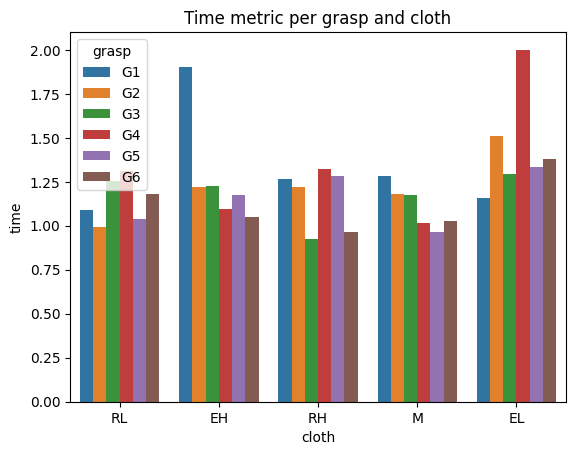

In [ ]:
# Bar plot for different cloth-types vs. grasps

import pandas as pd

# Load opt. results
with open('Optimisation_results.pkl', 'rb') as f:
    results_opt = pickle.load(f) # dictionary with the data

data_bar = []

# Loop over all stored results from above (will contain each pair cloth-grasp optimised above)
for (cloth_name, grasp_name), data in results_opt.items(): # get the data from dict. results_opt

    speeds = data['speeds']
    dt = data['dt']
    lam_knots = data['lam_knots']

    # Dense lambda values for plotting
    lam_dense = np.linspace(0, 1, 200)
    # Linear interpolation
    v_dense = np.interp(lam_dense, lam_knots, speeds)

    total_time = np.trapezoid(1/v_dense, lam_dense)

    data_bar.append({
        "cloth": cloth_name,
        "grasp": grasp_name,
        "time": total_time
     })

df_long = pd.DataFrame(data_bar)

# classify cloths into 3 weights classes
df_long["weight"] = df_long["cloth"].map({
    "EL": "light",
    "RL": "light",
    "EH": "heavy",
    "RH": "heavy",
    "M": "medium"

})

# classify cloths into 3 elastic classes
df_long["elasticity"] = df_long["cloth"].map({
    "EL": "elastic",
    "RL": "rigid",
    "EH": "elastic",
    "RH": "rigid",
    "M": "medium"
})

# ranking of best grasps per cloth-type (rank 1 = best grasp w/ least wrinkling)
df_long["fast"] = df_long.groupby("cloth")["time"] \
                          .rank(method="min", ascending=True)

import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure()
sns.barplot(data=df_long, x="cloth", y="time", hue="grasp")
plt.title("Time metric per grasp and cloth")
plt.show()


cloth   EH   EL    M   RH   RL
grasp                         
G1     6.0  1.0  6.0  4.0  3.0
G2     4.0  5.0  5.0  3.0  1.0
G3     5.0  2.0  4.0  1.0  5.0
G4     2.0  6.0  2.0  6.0  6.0
G5     3.0  3.0  1.0  5.0  2.0
G6     1.0  4.0  3.0  2.0  4.0
cloth        EH        EL         M        RH        RL
cloth                                                  
EH     1.000000 -0.714286  0.714286 -0.200000 -0.257143
EL    -0.714286  1.000000 -0.428571  0.371429  0.142857
M      0.714286 -0.428571  1.000000 -0.428571 -0.257143
RH    -0.200000  0.371429 -0.428571  1.000000  0.028571
RL    -0.257143  0.142857 -0.257143  0.028571  1.000000


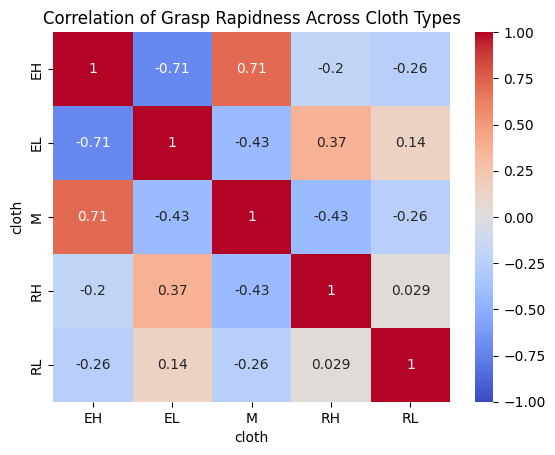

In [220]:
# construct the ranking matrix to do correlation

rank_matrix = df_long.pivot(index="grasp", 
                            columns="cloth", 
                            values="fast")

print(rank_matrix)

# correlation 
rank_corr = rank_matrix.corr()
print(rank_corr)

# draw correlation matrix

import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure()
sns.heatmap(rank_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Grasp Rapidness Across Cloth Types")
plt.show()

          G1        G2        G3        G4        G5        G6
G1  1.000000  0.051772  0.181903  0.299914  0.058262  0.045214
G2  0.051772  1.000000  0.515277  0.070847  0.245219  0.562068
G3  0.181903  0.515277  1.000000  0.106990 -0.116414  0.213757
G4  0.299914  0.070847  0.106990  1.000000  0.618117  0.441039
G5  0.058262  0.245219 -0.116414  0.618117  1.000000  0.250369
G6  0.045214  0.562068  0.213757  0.441039  0.250369  1.000000


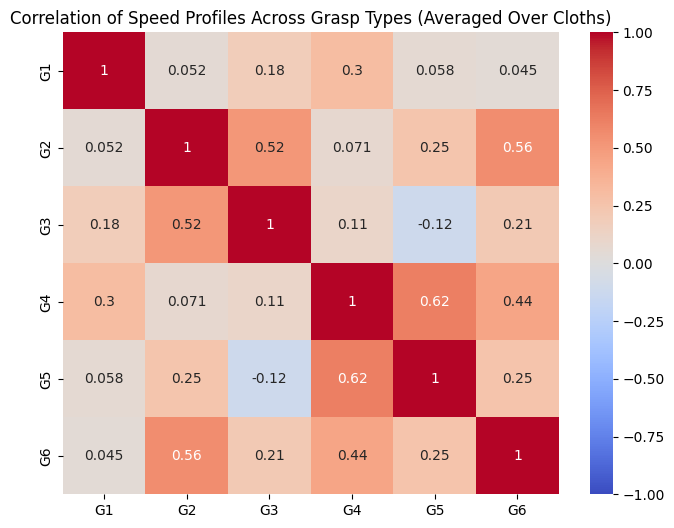

In [ ]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load opt. results
with open('Optimisation_results.pkl', 'rb') as f:
    results_opt = pickle.load(f)

# Get unique grasps and cloths
grasps = sorted({grasp for (_, grasp) in results_opt.keys()})
cloths = sorted({cloth for (cloth, _) in results_opt.keys()})

# Compute correlation matrix for grasps
n_grasps = len(grasps)
corr_matrix_grasps = np.zeros((n_grasps, n_grasps))

for i in range(n_grasps):
    for j in range(n_grasps):
        grasp_i = grasps[i]
        grasp_j = grasps[j]
        correlations = []
        for cloth in cloths:
            key_i = (cloth, grasp_i)
            key_j = (cloth, grasp_j)
            if key_i in results_opt and key_j in results_opt:
                speeds_i = np.array(results_opt[key_i]['speeds'])
                speeds_j = np.array(results_opt[key_j]['speeds'])
                corr = np.corrcoef(speeds_i, speeds_j)[0, 1]
                correlations.append(corr)
        if correlations:
            corr_matrix_grasps[i, j] = np.mean(correlations)
        else:
            corr_matrix_grasps[i, j] = np.nan  # If no data

# Create DataFrame
corr_df_grasps = pd.DataFrame(corr_matrix_grasps, index=grasps, columns=grasps)

print(corr_df_grasps)

# Visualize as heatmap
fig = plt.figure(figsize=(8, 6))
sns.heatmap(corr_df_grasps, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Speed Profiles Across Grasp Types (Averaged Over Cloths)")
plt.show()

          EH        EL         M        RH        RL
EH  1.000000  0.346093  0.644769  0.272588  0.555935
EL  0.346093  1.000000  0.237971  0.105491  0.572585
M   0.644769  0.237971  1.000000  0.488044  0.482992
RH  0.272588  0.105491  0.488044  1.000000  0.129075
RL  0.555935  0.572585  0.482992  0.129075  1.000000


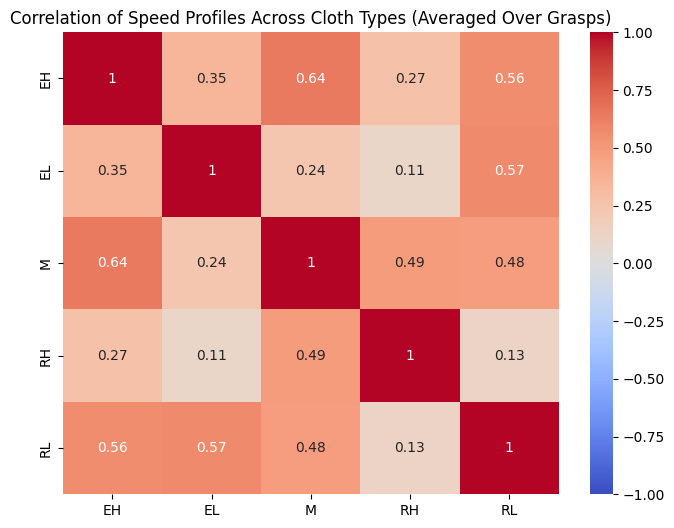

In [225]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load opt. results
with open('Optimisation_results.pkl', 'rb') as f:
    results_opt = pickle.load(f)

# Get unique grasps and cloths
grasps = sorted({grasp for (_, grasp) in results_opt.keys()})
cloths = sorted({cloth for (cloth, _) in results_opt.keys()})

# Compute correlation matrix for cloths
n_cloths = len(cloths)
corr_matrix_cloths = np.zeros((n_cloths, n_cloths))

for i in range(n_cloths):
    for j in range(n_cloths):
        cloth_i = cloths[i]
        cloth_j = cloths[j]
        correlations = []
        for grasp in grasps:
            key_i = (cloth_i, grasp)
            key_j = (cloth_j, grasp)
            if key_i in results_opt and key_j in results_opt:
                speeds_i = np.array(results_opt[key_i]['speeds'])
                speeds_j = np.array(results_opt[key_j]['speeds'])
                corr = np.corrcoef(speeds_i, speeds_j)[0, 1]
                correlations.append(corr)
        if correlations:
            corr_matrix_cloths[i, j] = np.mean(correlations)
        else:
            corr_matrix_cloths[i, j] = np.nan  # If no data

# Create DataFrame
corr_df_cloths = pd.DataFrame(corr_matrix_cloths, index=cloths, columns=cloths)

print(corr_df_cloths)

# Visualize as heatmap
fig = plt.figure(figsize=(8, 6))
sns.heatmap(corr_df_cloths, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Speed Profiles Across Cloth Types (Averaged Over Grasps)")
plt.show()

---------------------------------------

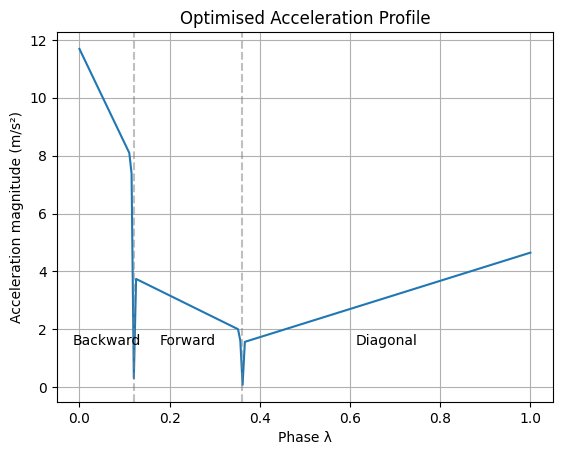

In [116]:
dv_dlam = np.gradient(v_dense, lam_dense)

p_dense = np.array([path_displacement(lam) for lam in lam_dense])
dp_dlam = np.gradient(p_dense, lam_dense, axis=0)   # shape (n, 3)

a_dense = dp_dlam * (dv_dlam * v_dense)[:, np.newaxis]   # shape (n, 3)
a_mag_dense = np.linalg.norm(a_dense, axis=1)

# Compute cumulative time for each dense λ
t_dense = np.zeros_like(lam_dense)
for i in range(1, len(lam_dense)):
    dt = (lam_dense[i] - lam_dense[i-1]) / ((v_dense[i] + v_dense[i-1])/2)  # average speed
    t_dense[i] = t_dense[i-1] + dt


plt.figure()
plt.plot(lam_dense, a_mag_dense)
plt.axvline(lam_a, color='gray', linestyle='--', alpha=0.5)
plt.axvline(lam_b, color='gray', linestyle='--', alpha=0.5)
plt.text(lam_a/2, max(speeds)*0.9, 'Backward', ha='center')
plt.text((lam_a+lam_b)/2, max(speeds)*0.9, 'Forward', ha='center')
plt.text((lam_b+1)/2, max(speeds)*0.9, 'Diagonal', ha='center')
plt.xlabel('Phase λ')
plt.ylabel('Acceleration magnitude (λ/s²)')
plt.title('Optimised Acceleration Profile')
plt.grid(True)
plt.show()

----------------------------------------

Plotting of the trajectories with speed mapping

In [38]:
def run_simulation_record_trajectory(best_speeds, cloth_name, grasp_name, lam_knots, dt_fixed):
    """
    Re-runs simulation with optimal speeds, recording positions and lambda speed
    at each step for trajectory plotting.
    Returns: dict with 'positions' (n_steps, n_nodes, 3) and 'speeds' (n_steps,)
    """
    import numpy as np

    X, T, na, nb = create_initial_mesh()
    cloth = Cloth(X, T, f"traj_{cloth_name}_{grasp_name}")
    params = CLOTH_TYPES[cloth_name]
    inds_ctr = get_grasp_config(grasp_name, na)
    dt = dt_fixed

    cloth.setSimulatorParameters(
        dt=dt, tol=params["tol"], rho=params["rho"],
        delta=params["delta"], alpha=params["alpha"], kappa=params["kappa"],
        str=params["str"], shr=params["shr"], mu_f=params["mu_f"],
        mu_s=params["mu_s"], thck=params["thck"],
    )
    cloth.restart()

    # Stabilisation
    u = cloth.positions[inds_ctr]
    center = u.mean(axis=0)
    u = center + (u - center) * 0.95
    for _ in range(200):
        cloth.simulate(u=u, control=inds_ctr)

    p0 = cloth.positions[inds_ctr].copy()
    lam_seq = generate_lambda_sequence(best_speeds, lam_knots, dt)

    # Record trajectory
    positions_over_time = []   # position of every node at each step
    speed_at_step = []         # lambda speed at each step

    for i in range(len(lam_seq) - 1):
        lam_cur = lam_seq[i]
        lam_next = lam_seq[i + 1]
        target = p0 + path_displacement(lam_next)
        cloth.simulate(u=target, control=inds_ctr)

        positions_over_time.append(cloth.positions.copy())   # shape: (n_nodes, 3)
        dlam = lam_next - lam_cur
        speed_at_step.append(cloth.velocities.copy()) # lambda-space speed (1/s)

    print(f'Lenght of Motion Position History: {len(positions_over_time)}')

    return {
        "positions": np.array(positions_over_time),   # (n_steps, n_nodes, 3)
        "speeds": np.array(speed_at_step),            # (n_steps,)
        "lam_seq": lam_seq,
        "dt": dt,
    }

In [61]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

def plot_node_trajectory_3d_colorspeed(traj_data, node_id=0, figsize=(9, 7),
                                        cmap_name="plasma", elev=25, azim=45):
    """
    3D trajectory of a single node colored by lambda speed.

    elev, azim: initial camera angles (degrees) — adjust to best view your cloth.
    """
    positions = traj_data["positions"]   # (n_steps, n_nodes, 3)
    speeds    = traj_data["speeds"]      # (n_steps,)

    node_pos = positions[:, node_id, :]  # (n_steps, 3)
    node_vel = speeds[:, node_id, :]          # (n_steps, 3)
    speeds = np.linalg.norm(node_vel, axis=1)  # (n_steps,) — magnitude
    x = node_pos[:, 0]
    y = node_pos[:, 1]
    z = node_pos[:, 2]

    # hard-code limits for color bar, so all under same one!
    norm = mcolors.Normalize(vmin=0, vmax=2.3)
    cmap = cm.get_cmap(cmap_name)

    # Build Line3DCollection — one segment per step
    points = np.stack([x, y, z], axis=1)             # (n_steps, 3)
    segments = np.stack([points[:-1], points[1:]], axis=1)  # (n_steps-1, 2, 3)
    colors = cmap(norm(speeds[:-1]))                  # one color per segment

    lc = Line3DCollection(segments, colors=colors, linewidth=2)

    fig = plt.figure(figsize=figsize)
    ax  = fig.add_subplot(111, projection="3d")
    ax.add_collection3d(lc)

    # Start / end markers
    ax.scatter(x[0],  y[0],  z[0],  color="green", s=80, zorder=5, label="Start",
               depthshade=False)
    ax.scatter(x[-1], y[-1], z[-1], color="red",   s=80, zorder=5, label="End",
               depthshade=False)

    # Axis limits — must be set manually for Line3DCollection
    for set_lim, data in zip(
        [ax.set_xlim, ax.set_ylim, ax.set_zlim], [x, y, z]
    ):
        pad = ((data.max() - data.min()) or 0.01) * 0.1
        set_lim(np.floor((data.min() - pad) * 100) / 100,
            np.ceil( (data.max() + pad) * 100) / 100)


    ax.set_ylim(-0.65, 0.35) 

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, pad=0.1, label="Lambda speed (λ/s)")

    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_title("Trajectory with the Speed Mapping")
    ax.legend()
    ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    plt.show()

    return fig

Lenght of Motion Position History: 486


/var/folders/l5/4jphj2ns2zj_nmbq6c0y64p00000gn/T/ipykernel_6577/1138170623.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


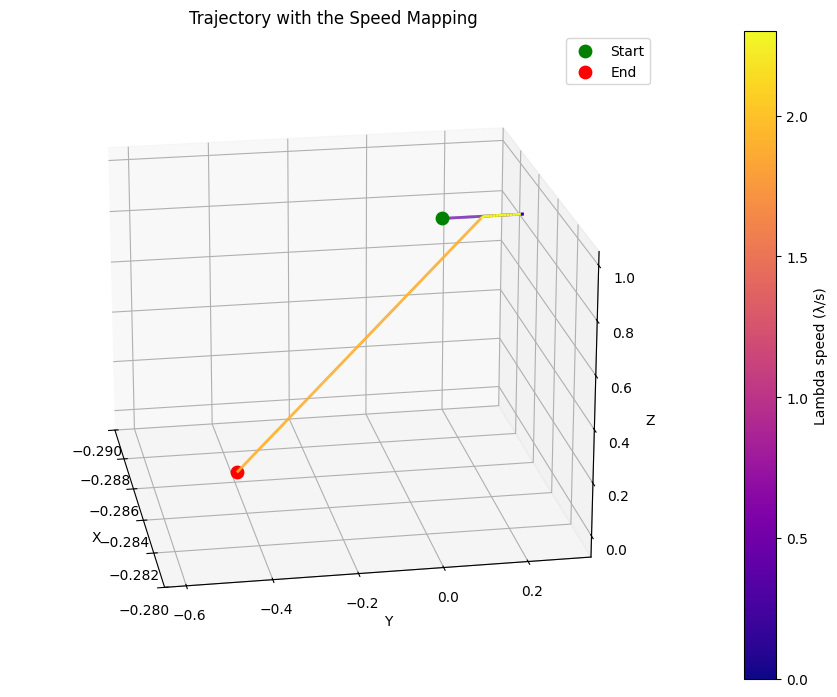

In [66]:
# Load your results
import pickle
with open("Optimisation_newtraj_constant.pkl", "rb") as f:
    results_opt = pickle.load(f)

cloth_name, grasp_name = "RH", "G1"
res = results_opt[(cloth_name, grasp_name)]

# Re-run with optimal speeds
traj = run_simulation_record_trajectory(
    best_speeds=res["speeds"],
    cloth_name=cloth_name,
    grasp_name=grasp_name,
    lam_knots=res["lam_knots"],
    dt_fixed=res["dt"],
)

# Plot node 0 trajectory with speed colormap
fig = plot_node_trajectory_3d_colorspeed(traj, node_id=0, elev=20, azim=-10)

name = "Traj_Speed_Newtraj.png"
fig.savefig(name, dpi=300, bbox_inches='tight')

In [63]:
# total motion time
print(f'Total motion time new trajectory: {486*dt}')

Total motion time new trajectory: 1.152469129283669


Lenght of Motion Position History: 440


/var/folders/l5/4jphj2ns2zj_nmbq6c0y64p00000gn/T/ipykernel_6577/1138170623.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


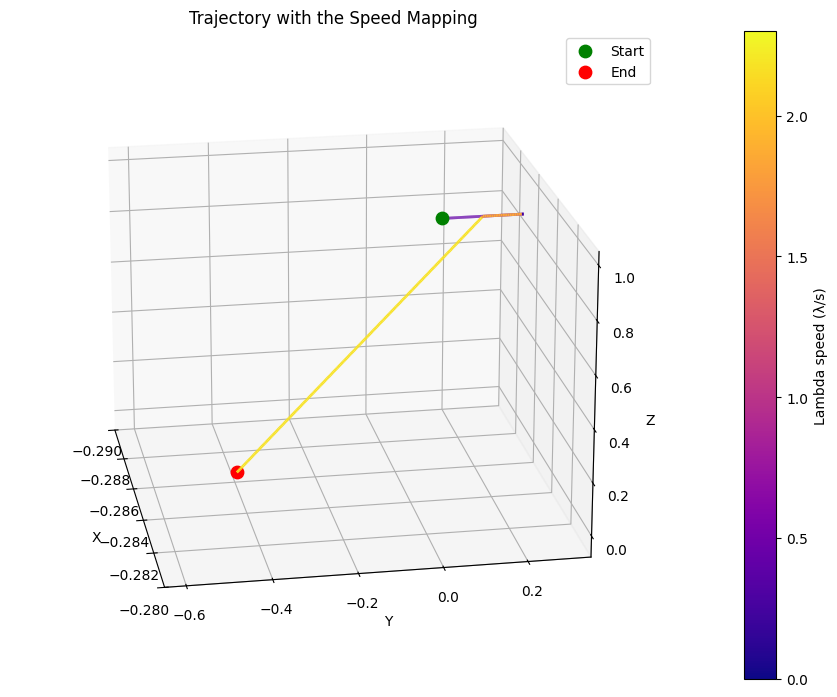

In [ ]:
# Load your results
import pickle
with open("Optimisation_newtraj_constant_time.pkl", "rb") as f:
    results_opt = pickle.load(f)

cloth_name, grasp_name = "RH", "G1"
res = results_opt[(cloth_name, grasp_name)]

# Re-run with optimal speeds
traj = run_simulation_record_trajectory(
    best_speeds=res["speeds"],
    cloth_name=cloth_name,
    grasp_name=grasp_name,
    lam_knots=res["lam_knots"],
    dt_fixed=res["dt"],
)

# Plot node 0 trajectory with speed colormap
fig = plot_node_trajectory_3d_colorspeed(traj, node_id=0, elev=20, azim=-10)

name = "Traj_Speed_Newtraj_Time.png"
fig.savefig(name, dpi=300, bbox_inches='tight')

In [60]:
# total motion time
print(f'Total motion time new trajectory: {440*dt}')

Total motion time new trajectory: 1.043387689063404


Plot lambda progression for speed profile

In [39]:
def plot_lambda_progression(traj_data, lam_knots, cloth_name, grasp_name, figsize=(8, 4)):
    lam_seq = np.array(traj_data["lam_seq"])  # (n_steps+1,)
    dt = traj_data["dt"]
    time_vec = np.arange(len(lam_seq)) * dt

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(time_vec, lam_seq, color="steelblue", linewidth=1.5)

    # Phase transition lines
    for i, lk in enumerate(lam_knots):
        ax.axhline(lk, color="gray", linestyle="--", linewidth=0.8)
        ax.text(time_vec[-1] * 1.01, lk, f"λ={lk:.3f}", fontsize=8,
                color="gray", va="center")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Lambda (λ)")
    ax.set_ylim(0, 1)
    ax.set_xlim(time_vec[0], time_vec[-1])
    ax.set_title(f"Lambda progression")
    
    phase_colors = ['red', 'orange', 'green']
    boundaries = [0, lam_knots[1], lam_knots[2], 1.0]
    for i in range(3):
        # find time where lam crosses each boundary
        t_start = time_vec[np.searchsorted(lam_seq, boundaries[i])]
        t_end   = time_vec[np.searchsorted(lam_seq, boundaries[i+1]) - 1]
        ax.axvspan(t_start, t_end, color=phase_colors[i], alpha=0.25,
                   label=f"Phase {i+1}")
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()
    
    return fig

Lenght of Motion Position History: 486


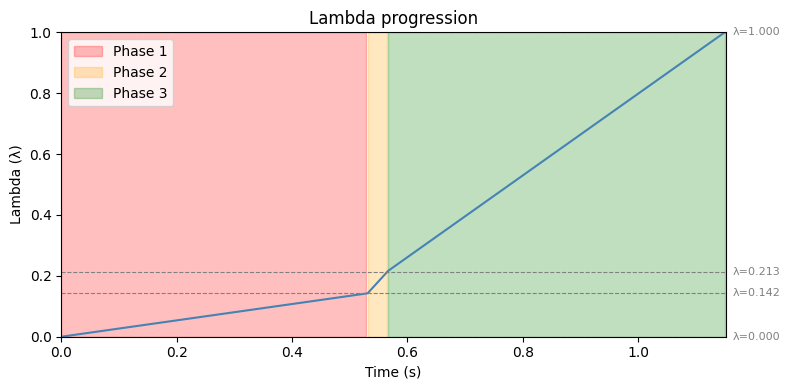

: 

In [ ]:
# Load your results
import pickle
with open("Optimisation_newtraj.pkl", "rb") as f:
    results_opt = pickle.load(f)

cloth_name, grasp_name = "RH", "G1"
res = results_opt[(cloth_name, grasp_name)]

# Re-run with optimal speeds
traj = run_simulation_record_trajectory(
    best_speeds=res["speeds"],
    cloth_name=cloth_name,
    grasp_name=grasp_name,
    lam_knots=res["lam_knots"],
    dt_fixed=res["dt"],
)


fig = plot_lambda_progression(traj, lam_knots, cloth_name, grasp_name)
name = "LamProgr_NewTraj_SpeedOpt.png"
fig.savefig(name, dpi=300, bbox_inches='tight')

Lenght of Motion Position History: 479


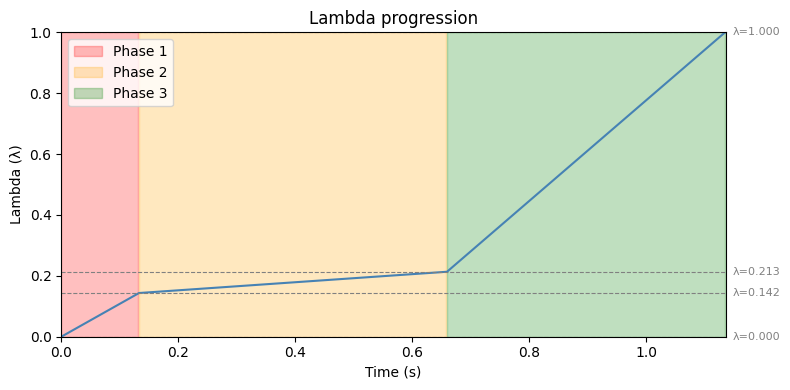

In [42]:
# Load your results
import pickle
with open("Optimisation_newtraj_time_0.01.pkl", "rb") as f:
    results_opt = pickle.load(f)

cloth_name, grasp_name = "RH", "G1"
res = results_opt[(cloth_name, grasp_name)]

# Re-run with optimal speeds
traj = run_simulation_record_trajectory(
    best_speeds=res["speeds"],
    cloth_name=cloth_name,
    grasp_name=grasp_name,
    lam_knots=res["lam_knots"],
    dt_fixed=res["dt"],
)


fig = plot_lambda_progression(traj, lam_knots, cloth_name, grasp_name)
name = "LamProgr_NewTraj_SpeedOpt_Time_0.01.png"
fig.savefig(name, dpi=300, bbox_inches='tight')

Get actual simulation times vs. ideally calculated ones

In [26]:
dt = 0.00237
best_speeds = [0.0, 0.27, 2.07, 1.34] # no time
# best_speeds = [0.0, 0.3, 1.3, 1.55] # time
lam_seq = generate_lambda_sequence(best_speeds, lam_knots, dt)
T_sim        = (len(lam_seq) - 1) * dt
T_analytical = L1/best_speeds[1] + L2/best_speeds[2] + L3/best_speeds[3]
print(f"Sim time:        {T_sim:.4f} s")
print(f"Analytical time: {T_analytical:.4f} s")
print(f"Difference:      {T_sim - T_analytical:.4f} s")





Sim time:        11.8500 s
Analytical time: 1.6150 s
Difference:      10.2350 s


In [30]:
np.array(traj["lam_seq"]).shape

(487,)

In [82]:
1041/8
130/20
1041*dt

np.float64(2.4685604188977353)

In [31]:
440*dt
486*dt

1.15182

In [60]:
11.857/dt
print(len(lam_seq))
print(dt)
print(len(history_pos))

5001
0.002371335656962282


NameError: name 'history_pos' is not defined

Plot contribution of each phase

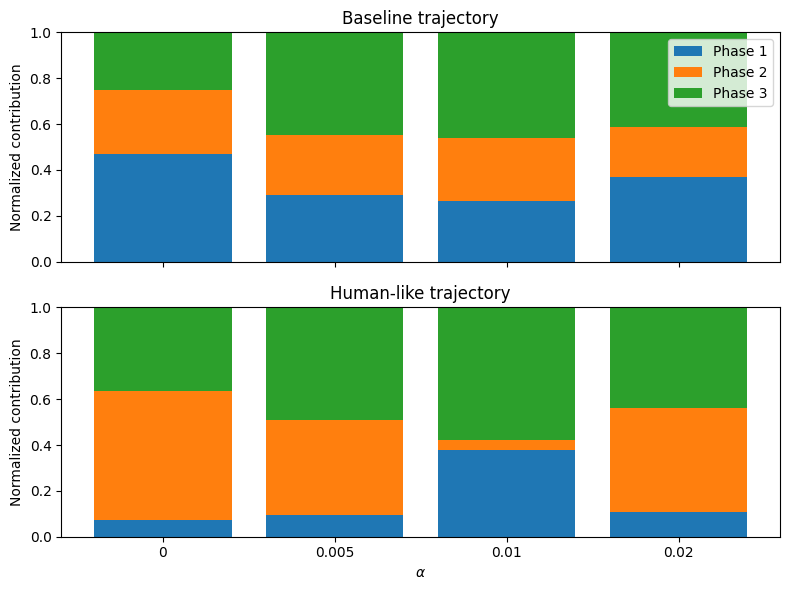

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# DATA
# ==========================

alphas = ['0', '0.005', '0.01', '0.02']

baseline = np.array([
    [1.52, 0.91, 0.81],
    [0.73, 0.65, 1.12],
    [0.65, 0.67, 1.12],
    [1.02, 0.61, 1.15]
])

0.077+0.259+0.8

human = np.array([
    [0.27, 2.07, 1.34],
    [0.30, 1.30, 1.55],
    [1.08, 0.13, 1.66],
    [0.43, 1.85, 1.77]
])

# Normalize each row
baseline_norm = baseline / baseline.sum(axis=1, keepdims=True)
human_norm = human / human.sum(axis=1, keepdims=True)

# ==========================
# PLOT
# ==========================

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

labels = ['Phase 1', 'Phase 2', 'Phase 3']

# -------- Baseline --------
bottom = np.zeros(len(alphas))

for i in range(3):
    axs[0].bar(
        alphas,
        baseline_norm[:, i],
        bottom=bottom,
        label=labels[i]
    )
    bottom += baseline_norm[:, i]

axs[0].set_ylabel('Normalized contribution')
axs[0].set_title('Baseline trajectory')
axs[0].set_ylim([0, 1])
axs[0].legend()

# -------- Human-like --------
bottom = np.zeros(len(alphas))

for i in range(3):
    axs[1].bar(
        alphas,
        human_norm[:, i],
        bottom=bottom,
        label=labels[i]
    )
    bottom += human_norm[:, i]

axs[1].set_ylabel('Normalized contribution')
axs[1].set_xlabel(r'$\alpha$')
axs[1].set_title('Human-like trajectory')
axs[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

name = "Contribution_Speed_Opt.png"
fig.savefig(name, dpi=300, bbox_inches='tight')